# ABCA4 Missense Variant Pathogenicity Classification
## A Machine Learning Pipeline with ESM-2 Integration

### Project Overview

ABCA4 (ATP-binding cassette transporter A4) is a retinal-specific flippase responsible
for transporting N-retinylidene-phosphatidylethanolamine across the photoreceptor disc
membrane. Loss-of-function variants cause **Stargardt disease** (STGD1), the most common
inherited macular dystrophy, affecting approximately 1 in 8,000–10,000 individuals.

Clinical interpretation of ABCA4 missense variants is complicated by the gene's large
size (2,273 amino acids, 50 exons) and the high proportion of variants of uncertain
significance (VUS) in public databases. As of the current ClinVar release, over 800 ABCA4
missense variants lack definitive Pathogenic or Benign classification — a direct barrier
to genetic counselling and diagnosis.

### Objective

This notebook builds a supervised binary classification pipeline to:
1. Distinguish Pathogenic from Benign ABCA4 missense variants using a multi-modal
   feature set spanning structural, evolutionary, physicochemical, and deep learning signals
2. Evaluate three classifiers (Logistic Regression, Random Forest, XGBoost) and a
   stacked ensemble across multiple performance metrics
3. Apply the trained ensemble to reclassify 812 VUS with calibrated probability estimates

### Feature Modalities

| Category | Features | Source |
|---|---|---|
| Structural contacts | Bond counts, delta-contacts at multiple distance cutoffs | Arpeggio |
| Physicochemical | pI, volume, hydrophobicity, polar/charge changes | Envision |
| Evolutionary (MSA) | Conservation score, entropy, log2f variance | ConSurf, DeMaSk |
| Evolutionary (neural LM) | Log-likelihood ratio under ESM-2 35M | Meta ESM-2 |
| Stability | ΔΔG estimate | DDMut |
| Disorder | Intrinsic disorder, anchor score | IUPRED2, ANCHOR |
| Pathogenicity (ML) | AlphaMissense score and class | Google DeepMind |

### Dataset

- **Total variants:** 3,915 ABCA4 missense variants
- **Labelled:** 3,103 (1,803 Benign, 1,300 Pathogenic) — source: ClinVar + gnomAD
- **VUS (held out):** 812 variants — reclassified in Section 19–20
- **Class balance:** 58.1% Benign / 41.9% Pathogenic

In [1]:
# ─── Section 1: Imports ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, randint, uniform
from statsmodels.stats.multitest import multipletests
import re
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
!pip install fair-esm -q
import esm
import torch

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    make_scorer, matthews_corrcoef, roc_auc_score,
    roc_curve,
    f1_score, recall_score, precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

df = pd.read_csv('ABCA4_mutations_annotated_with_features.csv')

# Display basic information and statistics
print('--- Dataset Info ---')
display(df.info())
print('\n--- Column Names ---')
print(df.columns.tolist())
print('\n--- Descriptive Statistics ---')
display(df.describe(include='all'))
print('\n--- Null Values ---')
print(df.isnull().sum())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.2 MB/s eta 0:00:00
--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3915 entries, 0 to 3914
Columns: 137 entries, Variant to DDmut_score
dtypes: float64(17), int64(116), object(4)
memory usage: 4.1+ MB


None


--- Column Names ---
['Variant', 'Significance', 'Source', 'Annotation', 'Position', 'Covalent', 'VDWClash', 'VDW', 'Proximal', 'Hbond', 'WeakHbond', 'Ionic', 'Aromatic', 'Hydrophobic', 'Carbonyl', 'Polar', 'WeakPolar', 'PI-PI', 'Carbon-PI', 'Cation-PI', 'Donor-PI', 'MetalSulphur-PI', 'Amide-Amide', 'Amide-Ring', 'd_Covalent', 'd_VDWClash', 'd_VDW', 'd_Proximal', 'd_Hbond', 'd_WeakHbond', 'd_Ionic', 'd_Aromatic', 'd_Hydrophobic', 'd_Carbonyl', 'd_Polar', 'd_WeakPolar', 'd_PI-PI', 'd_Carbon-PI', 'd_Cation-PI', 'd_Donor-PI', 'd_MetalSulphur-PI', 'd_Amide-Amide', 'd_Amide-Ring', 'Hydro', 'Pos', 'Neg', 'Acc', 'Don', 'Aro', 'Sul', 'Neutral', 'HH:12.00', 'PP:12.00', 'HP_12_00', 'HH:11.50', 'PP:11.50', 'HP:11.50', 'HH:11.00', 'PP:11.00', 'HP:11.00', 'HH:10.50', 'PP:10.50', 'HP:10.50', 'HH:10.00', 'PP:10.00', 'HP:10.00', 'HH:9.50', 'PP:9.50', 'HP:9.50', 'HH:9.00', 'PP:9.00', 'HP:9.00', 'HH:8.50', 'PP:8.50', 'HP:8.50', 'HH:8.00', 'PP:8.00', 'HP:8.00', 'HH:7.50', 'PP:7.50', 'HP:7.50', 'HH:7.00'

,Variant,Significance,Source,Annotation,Position,Covalent,VDWClash,VDW,Proximal,Hbond,...,Envision_AA2_PSIC,Envision_delta_PSIC,Demask_matrix,Demask_log2f_var,Demask_entropy,Consurf_score,MTR_score,IUPRED_score,ANCHOR_score,DDmut_score
count,3915,3915,3915,3915,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,...,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000
unique,3915,3,5,13,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,D999G,Benign,gnomAD,Unannotated,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1803,1743,3850,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1147.694764,0.009195,1.988761,1.157344,66.409706,2.096041,...,-3.149472,1.473277,-0.224934,-13.477640,1.190208,-0.042256,0.917407,0.189012,0.236566,-0.575357
std,NaN,NaN,NaN,NaN,656.758228,0.095463,1.725067,1.214488,33.609038,1.483506,...,0.802610,1.110783,0.089160,8.516058,1.056116,1.002173,0.092960,0.189378,0.160268,0.863914
min,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-5.723000,-2.054000,-0.490600,-22.253500,0.000100,-1.110000,0.574000,0.000500,0.000000,-4.467615
25%,NaN,NaN,NaN,NaN,583.500000,0.000000,1.000000,0.000000,44.000000,1.000000,...,-3.628000,0.629000,-0.291100,-22.228750,0.137950,-0.862000,0.852000,0.040950,0.070800,-1.012271
50%,NaN,NaN,NaN,NaN,1143.000000,0.000000,2.000000,1.000000,67.000000,2.000000,...,-3.058000,1.366000,-0.200300,-8.959900,1.062100,-0.373000,0.924000,0.139000,0.264500,-0.269939
75%,NaN,NaN,NaN,NaN,1713.000000,0.000000,3.000000,2.000000,86.000000,3.000000,...,-2.609000,2.258000,-0.158000,-5.469800,2.009950,0.526000,0.981000,0.277750,0.374400,0.035999



--- Null Values ---
Variant          0
Significance     0
Source           0
Annotation       0
Position         0
                ..
Consurf_score    0
MTR_score        0
IUPRED_score     0
ANCHOR_score     0
DDmut_score      0
Length: 137, dtype: int64


### Section 1b — AlphaMissense Integration

AlphaMissense (Cheng et al., *Science* 2023) is a fine-tuned variant of AlphaFold2 trained
to predict missense pathogenicity from sequence and structural context. It provides two
outputs used here as features:

- **`am_pathogenicity`** — continuous score (0–1), where higher values indicate greater
  predicted pathogenicity
- **`am_class_encoded`** — ordinal encoding of the categorical classification:
  - `0` = likely_benign
  - `1` = ambiguous  
  - `2` = likely_pathogenic

The AlphaMissense TSV uses three-letter amino acid codes (e.g. `p.Gly65Arg`). A
three-to-one letter conversion is applied to match the single-letter variant notation
used throughout this pipeline (e.g. `G65R`).

**4 variants (all M1X start-loss variants) have no AlphaMissense score** — these are
imputed in Section 4b using the training set median to prevent data leakage.

In [2]:
# ─── Section 1b: Merge AlphaMissense Features into df ────────────────────

# Guard: skip merge if already done (prevents duplicate column error on re-run)
if 'am_pathogenicity' not in df.columns:

    am = pd.read_csv('AlphaMissense-Search-P78363.tsv', sep='\t', comment='#',
                     header=None,
                     names=['uniprot_id', 'uniprot_name', 'gene', 'transcript',
                            'protein_variant', 'canonical', 'ref_aa', 'pos',
                            'alt_aa', 'am_pathogenicity', 'am_class',
                            'extra1', 'extra2'])

    am = am[['protein_variant', 'am_pathogenicity', 'am_class']].copy()

    three_to_one = {
        'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C',
        'Gln':'Q','Glu':'E','Gly':'G','His':'H','Ile':'I',
        'Leu':'L','Lys':'K','Met':'M','Phe':'F','Pro':'P',
        'Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V'
    }

    def convert_variant(pvar):
        match = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', str(pvar))
        if not match:
            return None
        ref3, pos, alt3 = match.group(1), match.group(2), match.group(3)
        ref1 = three_to_one.get(ref3)
        alt1 = three_to_one.get(alt3)
        if ref1 and alt1:
            return f"{ref1}{pos}{alt1}"
        return None

    am['Variant'] = am['protein_variant'].apply(convert_variant)
    am = am.dropna(subset=['Variant'])

    am_class_map = {'likely_benign': 0, 'ambiguous': 1, 'likely_pathogenic': 2}
    am['am_class_encoded'] = am['am_class'].map(am_class_map)

    df = df.merge(
        am[['Variant', 'am_pathogenicity', 'am_class_encoded']],
        on='Variant', how='left'
    )

    print(f"New df shape: {df.shape}")

else:
    print("am_pathogenicity already in df — skipping merge.")

New df shape: (3915, 139)


### Section 1c — ABCA4 Reference Sequence

The canonical ABCA4 protein sequence (UniProt P78363, isoform 1, 2,273 residues) is
written to disk for use by the ESM-2 scoring engine in Section 1d.

The sequence is hardcoded here rather than fetched via API to ensure:
- **Reproducibility** — the exact sequence used is version-controlled in the notebook
- **Offline execution** — no network dependency at runtime
- **Integrity verification** — length is checked against the expected 2,273 residues
  before proceeding

In [3]:
# ─── Section 1c: Save ABCA4 FASTA to filesystem ───────────────────────────

fasta_text = """>sp|P78363|ABCA4_HUMAN Retinal-specific phospholipid-transporting ATPase ABCA4 OS=Homo sapiens OX=9606 GN=ABCA4 PE=1 SV=3
MGFVRQIQLLLWKNWTLRKRQKIRFVVELVWPLSLFLVLIWLRNANPLYSHHECHFPNKA
MPSAGMLPWLQGIFCNVNNPCFQSPTPGESPGIVSNYNNSILARVYRDFQELLMNAPESQ
HLGRIWTELHILSQFMDTLRTHPERIAGRGIRIRDILKDEETLTLFLIKNIGLSDSVVYL
LINSQVRPEQFAHGVPDLALKDIACSEALLERFIIFSQRRGAKTVRYALCSLSQGTLQWI
EDTLYANVDFFKLFRVLPTLLDSRSQGINLRSWGGILSDMSPRIQEFIHRPSMQDLLWVT
RPLMQNGGPETFTKLMGILSDLLCGYPEGGGSRVLSFNWYEDNNYKAFLGIDSTRKDPIY
SYDRRTTSFCNALIQSLESNPLTKIAWRAAKPLLMGKILYTPDSPAARRILKNANSTFEE
LEHVRKLVKAWEEVGPQIWYFFDNSTQMNMIRDTLGNPTVKDFLNRQLGEEGITAEAILN
FLYKGPRESQADDMANFDWRDIFNITDRTLRLVNQYLECLVLDKFESYNDETQLTQRALS
LLEENMFWAGVVFPDMYPWTSSLPPHVKYKIRMDIDVVEKTNKIKDRYWDSGPRADPVED
FRYIWGGFAYLQDMVEQGITRSQVQAEAPVGIYLQQMPYPCFVDDSFMIILNRCFPIFMV
LAWIYSVSMTVKSIVLEKELRLKETLKNQGVSNAVIWCTWFLDSFSIMSMSIFLLTIFIM
HGRILHYSDPFILFLFLLAFSTATIMLCFLLSTFFSKASLAAACSGVIYFTLYLPHILCF
AWQDRMTAELKKAVSLLSPVAFGFGTEYLVRFEEQGLGLQWSNIGNSPTEGDEFSFLLSM
QMMLLDAAVYGLLAWYLDQVFPGDYGTPLPWYFLLQESYWLGGEGCSTREERALEKTEPL
TEETEDPEHPEGIHDSFFEREHPGWVPGVCVKNLVKIFEPCGRPAVDRLNITFYENQITA
FLGHNGAGKTTTLSILTGLLPPTSGTVLVGGRDIETSLDAVRQSLGMCPQHNILFHHLTV
AEHMLFYAQLKGKSQEEAQLEMEAMLEDTGLHHKRNEEAQDLSGGMQRKLSVAIAFVGDA
KVVILDEPTSGVDPYSRRSIWDLLLKYRSGRTIIMSTHHMDEADLLGDRIAIIAQGRLYC
SGTPLFLKNCFGTGLYLTLVRKMKNIQSQRKGSEGTCSCSSKGFSTTCPAHVDDLTPEQV
LDGDVNELMDVVLHHVPEAKLVECIGQELIFLLPNKNFKHRAYASLFRELEETLADLGLS
SFGISDTPLEEIFLKVTEDSDSGPLFAGGAQQKRENVNPRHPCLGPREKAGQTPQDSNVC
SPGAPAAHPEGQPPPEPECPGPQLNTGTQLVLQHVQALLVKRFQHTIRSHKDFLAQIVLP
ATFVFLALMLSIVIPPFGEYPALTLHPWIYGQQYTFFSMDEPGSEQFTVLADVLLNKPGF
GNRCLKEGWLPEYPCGNSTPWKTPSVSPNITQLFQKQKWTQVNPSPSCRCSTREKLTMLP
ECPEGAGGLPPPQRTQRSTEILQDLTDRNISDFLVKTYPALIRSSLKSKFWVNEQRYGGI
SIGGKLPVVPITGEALVGFLSDLGRIMNVSGGPITREASKEIPDFLKHLETEDNIKVWFN
NKGWHALVSFLNVAHNAILRASLPKDRSPEEYGITVISQPLNLTKEQLSEITVLTTSVDA
VVAICVIFSMSFVPASFVLYLIQERVNKSKHLQFISGVSPTTYWVTNFLWDIMNYSVSAG
LVVGIFIGFQKKAYTSPENLPALVALLLLYGWAVIPMMYPASFLFDVPSTAYVALSCANL
FIGINSSAITFILELFENNRTLLRFNAVLRKLLIVFPHFCLGRGLIDLALSQAVTDVYAR
FGEEHSANPFHWDLIGKNLFAMVVEGVVYFLLTLLVQRHFFLSQWIAEPTKEPIVDEDDD
VAEERQRIITGGNKTDILRLHELTKIYPGTSSPAVDRLCVGVRPGECFGLLGVNGAGKTT
TFKMLTGDTTVTSGDATVAGKSILTNISEVHQNMGYCPQFDAIDELLTGREHLYLYARLR
GVPAEEIEKVANWSIKSLGLTVYADCLAGTYSGGNKRKLSTAIALIGCPPLVLLDEPTTG
MDPQARRMLWNVIVSIIREGRAVVLTSHSMEECEALCTRLAIMVKGAFRCMGTIQHLKSK
FGDGYIVTMKIKSPKDDLLPDLNPVEQFFQGNFPGSVQRERHYNMLQFQVSSSSLARIFQ
LLLSHKDSLLIEEYSVTQTTLDQVFVNFAKQQTESHDLPLHPRAAGASRQAQD"""

with open('P78363.fasta', 'w') as f:
    f.write(fasta_text)

print("Saved P78363.fasta")

# Verify
with open('P78363.fasta') as f:
    lines = f.readlines()
seq = ''.join(l.strip() for l in lines if not l.startswith('>'))
print(f"Sequence length: {len(seq)} residues (should be 2273)")

Saved P78363.fasta
Sequence length: 2273 residues (should be 2273)


### Section 1d — ESM-2 Log-Likelihood Ratio Scoring

#### What is ESM-2?

ESM-2 (Evolutionary Scale Modeling 2; Lin et al., *Science* 2023) is a protein language model trained on UniRef50
sequences using a masked language modelling objective
— the same self-supervised approach as BERT in NLP. The model learns to predict masked
amino acids from their sequence context, encoding evolutionary constraints, co-evolutionary
dependencies, and structural propensities entirely from sequence.

The model used here (`esm2_t12_35M_UR50D`) has 12 transformer layers and 35 million
parameters — the smallest ESM-2 variant, chosen for computational efficiency while
retaining strong per-position scoring capability.

#### Why ESM-2 Adds Independent Signal

All other evolutionary features in this pipeline (ConSurf, DeMaSk, Envision PSIC) are
derived from **multiple sequence alignments (MSAs)** — they quantify how conserved a
position is across homologous sequences. ESM-2 takes a fundamentally different approach:
it learns evolutionary constraints implicitly through a neural network with no MSA at
inference time. This means it can capture:

- **Long-range co-evolutionary dependencies** across the full 2,273-residue sequence
  simultaneously (transformer attention is global, not positional)
- **Context-sensitive substitution tolerance** — the same amino acid change may be
  tolerated at one position but not another depending on its structural neighbourhood
- **Signal for rare proteins** where MSA depth is limited

#### The Log-Likelihood Ratio (LLR)

For each variant, the LLR is computed as:

$$\text{LLR} = \log P(\text{alt} \mid \text{context}) - \log P(\text{ref} \mid \text{context})$$

Where probabilities are obtained by:
1. Masking the target position in the wildtype sequence
2. Running a forward pass through ESM-2
3. Applying log-softmax to the logits at the masked position

**Interpretation:**
- **LLR < 0** → the mutant amino acid is evolutionarily surprising at this position
  → **Pathogenic signal**
- **LLR > 0** → the mutant is tolerated or even preferred → **Benign signal**
- Range in this dataset: −12.47 to +3.34

#### Known Limitation — Start-Loss Variants

M1X variants (M1V, M1L, M1T, M1I) are pathogenic through **loss of translation
initiation**, not protein instability. ESM-2 assigns positive LLR to these variants
(methionine is conserved at position 1, but the model does not know that losing it
abolishes translation). These variants are retained in the dataset but this limitation
is noted — their pathogenicity mechanism is invisible to sequence-based scoring.

In [4]:
# ─── Section 1d: ESM-2 Log-Likelihood Ratio Scoring ──────────────────────

# ── Load sequence ─────────────────────────────────────────────────────────
with open('P78363.fasta') as f:
    lines = f.readlines()
wt_seq = ''.join(l.strip() for l in lines if not l.startswith('>'))
print(f"ABCA4 sequence loaded: {len(wt_seq)} residues")

# ── Load ESM-2 35M model ──────────────────────────────────────────────────
# esm2_t12_35M_UR50D: 12 layers, 35M parameters
# Fast enough on T4 GPU (~3-5 min for all variants), better than 8M
model_esm, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
model_esm = model_esm.eval().cuda()   # move to GPU
batch_converter = alphabet.get_batch_converter()
print("ESM-2 35M model loaded on GPU.")

# ── Parse variants from df ────────────────────────────────────────────────
# Variant format in your df: 'G65R' = ref G, position 65, alt R

def parse_variant(v):
    """Returns (ref_aa, pos_0idx, alt_aa) or None if unparseable."""
    m = re.match(r'^([A-Z])(\d+)([A-Z])$', str(v))
    if not m:
        return None
    ref, pos, alt = m.group(1), int(m.group(2)), m.group(3)
    pos_0 = pos - 1   # convert to 0-indexed
    if pos_0 < 0 or pos_0 >= len(wt_seq):
        return None
    if wt_seq[pos_0] != ref:
        # Reference mismatch — skip silently
        return None
    return ref, pos_0, alt

# ── Score all variants ────────────────────────────────────────────────────
# ESM-2 LLR is computed by:
# 1. Mask the target position in the sequence
# 2. Get log-softmax probabilities over all 20 amino acids at that position
# 3. LLR = log P(alt) - log P(ref)

@torch.no_grad()
def score_variant(ref_aa, pos_0, alt_aa, sequence):
    """Compute ESM-2 LLR for a single variant."""
    masked_seq = sequence[:pos_0] + '<mask>' + sequence[pos_0+1:]
    data = [("protein", masked_seq)]
    _, _, tokens = batch_converter(data)
    tokens = tokens.cuda()

    results = model_esm(tokens, repr_layers=[], return_contacts=False)
    logits = results['logits'][0, pos_0 + 1]  # +1 for BOS token
    log_probs = torch.log_softmax(logits, dim=-1)

    ref_idx = alphabet.get_idx(ref_aa)
    alt_idx = alphabet.get_idx(alt_aa)
    llr = (log_probs[alt_idx] - log_probs[ref_idx]).item()
    return llr

print(f"\nScoring {len(df)} variants with ESM-2...")
print("This will take ~3-5 minutes on T4 GPU.\n")

esm_scores = []
skipped = 0

for i, row in df.iterrows():
    parsed = parse_variant(row['Variant'])
    if parsed is None:
        esm_scores.append(np.nan)
        skipped += 1
    else:
        ref, pos_0, alt = parsed
        llr = score_variant(ref, pos_0, alt, wt_seq)
        esm_scores.append(llr)

    if (i + 1) % 500 == 0:
        print(f"  Scored {i+1}/{len(df)} variants...")

df['esm2_llr'] = esm_scores

print(f"\nDone. Skipped {skipped} unparseable variants.")
print(f"ESM-2 LLR range: {df['esm2_llr'].min():.3f} to {df['esm2_llr'].max():.3f}")
print(f"NaNs: {df['esm2_llr'].isnull().sum()}")
print(f"\nPreview:")
print(df[['Variant', 'Significance', 'esm2_llr']].head(10))

# ── Flag M1X start-loss variants (known ESM-2 limitation) ────────────────
# These are pathogenic via loss of translation initiation, not protein
# instability — ESM-2 LLR will be positive (wrong direction) for these.
# Flagged here for awareness; they remain in the dataset.
m1x_variants = df[df['Variant'].str.startswith('M1')]['Variant'].tolist()
print(f"\nM1X start-loss variants ({len(m1x_variants)} total): {m1x_variants}")
print("NOTE: ESM-2 LLR is unreliable for these — pathogenicity mechanism")
print("      is translational, not protein structural/evolutionary.")



ABCA4 sequence loaded: 2273 residues
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t12_35M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t12_35M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D-contact-regression.pt
ESM-2 35M model loaded on GPU.

Scoring 3915 variants with ESM-2...
This will take ~3-5 minutes on T4 GPU.

  Scored 500/3915 variants...
  Scored 1000/3915 variants...
  Scored 1500/3915 variants...
  Scored 2000/3915 variants...
  Scored 2500/3915 variants...
  Scored 3000/3915 variants...
  Scored 3500/3915 variants...

Done. Skipped 0 unparseable variants.
ESM-2 LLR range: -12.474 to 3.342
NaNs: 0

Preview:
  Variant Significance  esm2_llr
0     M1V   Pathogenic  0.972069
1     M1L   Pathogenic  1.554185
2     M1T   Pathogenic  0.960733
3     M1I   Pathogenic  0.813263
4    L10F       Benign -0.720090
5    L10V       Beni

## Section 2 — Label Encoding and Dataset Partitioning

The dataset is partitioned into three non-overlapping subsets that flow through the
pipeline with strict separation:

| Subset | n | Purpose |
|---|---|---|
| `labelled` (train + test) | 3,103 | Model training and evaluation |
| `vus` | 812 | Held out entirely — reclassified at the end |

Binary labels are assigned as:
- **Benign = 0** (1,803 variants, 58.1%)
- **Pathogenic = 1** (1,300 variants, 41.9%)

The 41.9% pathogenic proportion represents mild class imbalance. This is handled
downstream by `class_weight='balanced'` in Logistic Regression and Random Forest,
and `scale_pos_weight` in XGBoost — both approaches upweight minority class errors
during training without resampling the data.

**VUS variants never influence any training statistic** — they are separated here
before any modelling and only receive predictions in Section 19.

In [5]:
# ─── Section 2: Label Encoding + Split into Labelled vs VUS ───────────────

# Step 1: Separate metadata/label columns from numeric feature columns
metadata_cols = ['Variant', 'Significance', 'Source', 'Annotation']

# All columns that are NOT metadata are candidate features
feature_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Number of feature columns: {len(feature_cols)}")

# Step 2: Split the dataset into labelled variants and VUS
labelled = df[df['Significance'].isin(['Benign', 'Pathogenic'])].copy()
vus = df[df['Significance'] == 'VUS'].copy()

print(f"Labelled variants (Benign + Pathogenic): {len(labelled)}")
print(f"\nVUS variants (held out for reclassification): {len(vus)}")

# Step 3: Encode the binary label (Benign=0, Pathogenic=1)
labelled['label'] = labelled['Significance'].map({'Benign': 0, 'Pathogenic': 1})

print("\nLabel distribution:")
print(labelled['label'].value_counts())
print(f"\nClass balance: {labelled['label'].mean():.1%} pathogenic")

Number of feature columns: 136
Labelled variants (Benign + Pathogenic): 3103

VUS variants (held out for reclassification): 812

Label distribution:
label
0    1803
1    1300
Name: count, dtype: int64

Class balance: 41.9% pathogenic


## Section 3 — Feature Matrix Construction

`X` contains all 136 candidate features for the 3,103 labelled variants. These include
the 133 original features from the annotated dataset plus `am_pathogenicity`,
`am_class_encoded` (AlphaMissense, Section 1b), and `esm2_llr` (ESM-2, Section 1d).

`y` contains the binary Pathogenic/Benign labels.

Both are built with `.copy()` to ensure they are independent objects — this prevents
pandas `SettingWithCopyWarning` when features are added or modified in later sections.

The feature set at this stage is deliberately unreduced. Redundancy removal (VIF),
significance filtering (Mann-Whitney + FDR), and interaction engineering are performed
in Sections 5–14 using training data only.

In [6]:
# ─── Section 3: Build X and y ─────────────────────────────────────────────

X = labelled[feature_cols].copy()
y = labelled['label'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3103, 136)
y shape: (3103,)


## Sections 4–5 — Data Splitting, Imputation, and Multicollinearity Removal

### Train / Test Split (Section 4)

The labelled dataset is split 80/20 into training (2,482) and test (621) sets using
stratified sampling — `stratify=y` ensures both splits maintain the same 58.1/41.9%
Benign/Pathogenic ratio as the full dataset. `random_state=42` makes the split
deterministic and reproducible.

The VUS feature matrix (`X_vus`) is built here from the same 136 feature columns and
remains completely separate from all training and evaluation steps until Section 19.

### Train-Only Imputation (Section 4b)

Four M1X (start-loss) variants have no AlphaMissense score — these positions lie at the
translation initiation codon, which falls outside AlphaMissense's scoring range.

Imputation follows the same principle as fitting a scaler:

- `am_pathogenicity` → replaced with the **training set median** (0.2488)
- `am_class_encoded` → replaced with **1.0 (ambiguous)** — a fixed, conservative value
  not derived from data, reflecting genuine uncertainty about start-loss classification
- `esm2_llr` → training set median (−0.1914) applied as a safety net; no NaNs were
  present in this run

Applying training-derived values to test and VUS matrices ensures that no information
from those sets influences any statistic computed during training.

### VIF Multicollinearity Filter (Section 5)

**Why VIF before Mann-Whitney?**
Mann-Whitney tests each feature *independently* against the label. It cannot detect that
two features both separate Benign/Pathogenic *and* are near-linear combinations of each
other. VIF addresses multi-way linear redundancy — it quantifies how well each feature
is predicted by all others simultaneously.

The Variance Inflation Factor for feature *j* is:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the coefficient of determination from regressing feature *j* on all
remaining features.

| VIF value | Interpretation |
|---|---|
| 1 | No linear relationship with any other feature |
| 1–5 | Low to moderate collinearity — acceptable |
| 5–10 | Moderate — worth monitoring |
| > 10 | Severe — feature is nearly a linear combination of others |

An iterative greedy algorithm removes the feature with the highest VIF at each step,
recomputing all VIFs after each removal, until all remaining features satisfy VIF < 10.

**Results:** 81 of 136 features removed, 55 retained (max VIF = 9.11).

The dominant source of removal was the contact feature family — HH/PP/HP cumulative
counts at increasing distance cutoffs are near-perfect linear combinations of each other
(median pairwise r = 0.917, confirmed in Section 10). The four `Envision_AA1_*` reference
amino acid features were removed first with VIF = ∞, as they are constant for any given
position and perfectly collinear with position-level features.

Notably, `esm2_llr` survived VIF filtering with VIF = 1.95 — confirming it carries
genuinely independent signal not captured by any linear combination of the existing 135
features.

In [7]:
# ─── Section 4: Train / Test Split ────────────────────────────────────────

# Split: 80% train, 20% test
# stratify=y ensures each split maintains the ~58/42 Benign/Pathogenic ratio
# random_state=42 makes the split reproducible (same result every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(y_train.value_counts())

X_vus = vus[feature_cols].copy()
print(f"VUS feature matrix shape: {X_vus.shape}")

Training set: 2482 rows | Test set: 621 rows
label
0    1442
1    1040
Name: count, dtype: int64
VUS feature matrix shape: (812, 136)


In [8]:
# ─── Section 4b: Train-only imputation for AlphaMissense NaNs ────────────

train_am_median = X_train['am_pathogenicity'].median()
train_am_class_median = 1.0  # 'ambiguous' — fixed, not data-derived

X_train['am_pathogenicity']  = X_train['am_pathogenicity'].fillna(train_am_median)
X_train['am_class_encoded']  = X_train['am_class_encoded'].fillna(train_am_class_median)

X_test['am_pathogenicity']   = X_test['am_pathogenicity'].fillna(train_am_median)
X_test['am_class_encoded']   = X_test['am_class_encoded'].fillna(train_am_class_median)

X_vus['am_pathogenicity']    = X_vus['am_pathogenicity'].fillna(train_am_median)
X_vus['am_class_encoded']    = X_vus['am_class_encoded'].fillna(train_am_class_median)

print(f"Remaining NaNs after imputation: {X_train.isnull().sum().sum()} (train), "
      f"{X_test.isnull().sum().sum()} (test), {X_vus.isnull().sum().sum()} (VUS)")

train_esm_median = X_train['esm2_llr'].median()
X_train['esm2_llr'] = X_train['esm2_llr'].fillna(train_esm_median)
X_test['esm2_llr']  = X_test['esm2_llr'].fillna(train_esm_median)
X_vus['esm2_llr']   = X_vus['esm2_llr'].fillna(train_esm_median)
print(f"ESM-2 LLR NaN imputation median (train-only): {train_esm_median:.4f}")


Remaining NaNs after imputation: 0 (train), 0 (test), 0 (VUS)
ESM-2 LLR NaN imputation median (train-only): -0.1914


### Data Quality Audit (Section 4c)

Before proceeding to feature selection, all three feature matrices (`X_train`,
`X_test`, `X_vus`) are verified to contain zero missing values. This is enforced
with an `assert` statement that raises a descriptive error if any NaN is found,
identifying the worst-offending columns for targeted remediation.

This guard is placed *after* imputation (Section 4b) and *before* VIF and
Mann-Whitney filtering — ensuring that all downstream steps receive complete data.

In [36]:
# ─── Section 4c: Data Quality Audit (Missing Values) ───────────────────────────────────

print("─── Missing value audit ───")
for name, frame in [('X_train', X_train), ('X_test', X_test), ('X_vus', X_vus)]:
    n_missing = frame.isnull().sum().sum()
    print(f"  {name}: {n_missing} missing values")
    assert n_missing == 0, (
        f"{name} contains {n_missing} missing values. "
        f"Worst columns:\n{frame.isnull().mean().sort_values(ascending=False).head(5)}\n"
        f"Add a SimpleImputer before proceeding."
    )
print("All feature matrices are complete — no imputation needed.")

─── Missing value audit ───
  X_train: 0 missing values
  X_test: 0 missing values
  X_vus: 0 missing values
All feature matrices are complete — no imputation needed.


In [9]:
# ─── Section 5: VIF Filter (Multicollinearity Removal) ─────────────────

def iterative_vif_filter(X_df, threshold=10, verbose=True):
    """
    Iteratively removes the feature with the highest VIF until
    all remaining features have VIF < threshold.

    Guards against:
    - Zero-variance columns (VIF = inf) → removed first
    - NaN VIF values → treated as inf
    - Infinite loop when max VIF is NaN
    """
    cols = list(X_df.columns)
    vif_log = []
    step = 0

    # Pre-flight: drop zero-variance columns immediately
    # These cause division-by-zero inside variance_inflation_factor's OLS
    zero_var = [c for c in cols if X_df[c].std() == 0]
    if zero_var:
        if verbose:
            print(f"  Pre-flight: dropping {len(zero_var)} zero-variance column(s): {zero_var}")
        for c in zero_var:
            cols.remove(c)
            vif_log.append({'step': step, 'removed': c, 'vif': float('inf')})
            step += 1

    while True:
        n_nan = X_df[cols].isnull().sum().sum()
        if n_nan > 0:
            raise ValueError(
                f"VIF filter received {n_nan} missing values. "
                f"Fit a SimpleImputer on X_train before calling iterative_vif_filter()."
            )
        X_arr = X_df[cols].values.astype(float)
        vif_values = []
        for i in range(len(cols)):
            try:
                v = variance_inflation_factor(X_arr, i)
            except Exception:
                v = float('inf')   # treat any failure as infinite VIF
            vif_values.append(v)

        vif_series = pd.Series(vif_values, index=cols)

        max_vif = vif_series.replace([np.inf, -np.inf], np.nan).max()

        # Separately check for any inf values — treat as worst offender
        if vif_series.isin([np.inf]).any():
            worst_feature = vif_series[vif_series == np.inf].index[0]
        elif pd.isna(max_vif) or max_vif < threshold:
            break
        else:
            worst_feature = vif_series.idxmax()

        vif_log.append({'step': step, 'removed': worst_feature,
                        'vif': vif_series[worst_feature]})
        if verbose:
            print(f"  Step {step:>2}: removing '{worst_feature}' "
                  f"(VIF={vif_series[worst_feature]:.1f})")
        cols.remove(worst_feature)
        step += 1

    return cols, vif_log


print("─── VIF Filter (threshold = 10) ───")
print(f"Input: {X_train.shape[1]} features\n")

vif_kept_features, vif_removal_log = iterative_vif_filter(X_train, threshold=10, verbose=False)

print(f"\nFeatures removed: {len(vif_removal_log)}")
print(f"Features retained: {len(vif_kept_features)}")

# Show a summary table of what was removed and why
if vif_removal_log:
    vif_removed_df = pd.DataFrame(vif_removal_log)
    print("\n─── Removed features (highest VIF first) ───")
    print(vif_removed_df.to_string(index=False))

# Show the final VIF of retained features (all should be < 10)
X_arr_final = X_train[vif_kept_features].values.astype(float)
final_vif = pd.DataFrame({
    'Feature': vif_kept_features,
    'VIF': [variance_inflation_factor(X_arr_final, i)
            for i in range(len(vif_kept_features))]
}).sort_values('VIF', ascending=False)

print("\n─── All retained features by VIF (all should be < 10) ───")
print(final_vif.to_string(index=False))
print(f"\nMax VIF in retained set: {final_vif['VIF'].max():.2f}")

─── VIF Filter (threshold = 10) ───
Input: 136 features



/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Features removed: 81
Features retained: 55

─── Removed features (highest VIF first) ───
 step              removed          vif
    0      Envision_AA1_pI          inf
    1  Envision_AA1_weight          inf
    2  Envision_AA1_volume          inf
    3    Envision_AA1_PSIC          inf
    4             HP:11.50 3.055079e+05
    5             PP:11.50 2.271740e+05
    6             HP:10.50 2.193067e+05
    7             PP:10.50 1.889186e+05
    8             PP:10.00 1.366006e+05
    9              HP:9.50 1.326632e+05
   10             HP:11.00 1.108091e+05
   11              HP:9.00 1.027619e+05
   12              PP:9.00 9.791195e+04
   13             HH:11.00 7.793716e+04
   14              HP:8.00 7.625460e+04
   15              PP:8.00 7.164717e+04
   16             PP:11.00 5.578873e+04
   17             HH:11.50 5.168143e+04
   18             HH:10.00 4.829486e+04
   19              PP:7.50 4.639023e+04
   20              HP:7.50 4.626041e+04
   21              PP:6.50 3.8

## Sections 6–7 — Scaling, Baseline Models, and Data Quality Audit

### Feature Scaling (Section 6)

Logistic Regression requires features to be on a comparable scale — large-magnitude
features (e.g. `Position` spanning 1–2273) would otherwise dominate the gradient
updates and bias the learned coefficients.

`RobustScaler` is used rather than `StandardScaler` because several features
(particularly contact counts and structural scores) have heavy-tailed distributions
with biological outliers that should not distort the scaling parameters. RobustScaler
centres on the **median** and scales by the **interquartile range (IQR)**:

$$x_{\text{scaled}} = \frac{x - \text{median}(x)}{\text{IQR}(x)}$$

This makes it resistant to extreme values — a variant with an unusually large number
of VDW contacts does not shift the centre or compress the range for all other variants.

**Critical:** `.fit_transform()` is called on `X_train` only. `.transform()` (without
fitting) is used on `X_test` and `X_vus` — this ensures the median and IQR are always
computed from training data and applied identically to unseen data. Fitting the scaler
on test data would constitute **data leakage**.

Tree-based models (Random Forest, XGBoost) are scale-invariant — splits are determined
by rank order of feature values, not magnitude — so they receive raw unscaled features
throughout.

### Baseline Cross-Validation (Sections 6–7)

Three models are evaluated using 5-fold stratified cross-validation on `X_train`:

**Logistic Regression** — ElasticNet regularisation (`penalty='elasticnet'`,
`l1_ratio=0.5`) combines L1 sparsity (drives uninformative coefficients to zero) with
L2 shrinkage (stabilises correlated features). `solver='saga'` is required for
ElasticNet with large datasets. `C=1.0` is the inverse regularisation strength.

**Random Forest** — 500 trees with `class_weight='balanced'`, which reweights each
sample by the inverse of its class frequency:

$$w_i = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples in class}_i}}$$

This upweights Pathogenic variants during tree construction without resampling.

**XGBoost** — uses `scale_pos_weight = n_{negative} / n_{positive} =
1442/1040 = 1.3865`, which multiplies the gradient contribution of each Pathogenic
sample. `tree_method='hist'` uses histogram-based approximate splits — significantly
faster than exact splitting for datasets of this size with no accuracy cost.

Seven metrics are tracked per fold:

| Metric | Why it matters here |
|---|---|
| AUC-ROC | Threshold-independent discriminability |
| MCC | Primary metric — handles class imbalance correctly |
| F1 | Harmonic mean of precision and recall |
| Recall (sensitivity) | Proportion of true Pathogenic variants correctly identified |
| Specificity | Proportion of true Benign variants correctly identified |
| Precision | Of variants called Pathogenic, how many truly are |
| AUC-PR | Area under precision-recall curve — sensitive to minority class performance |

MCC (Matthews Correlation Coefficient) is the primary metric because it accounts for
all four cells of the confusion matrix simultaneously and is robust to class imbalance:

$$\text{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

A value of 0 indicates random performance; 1 is perfect classification; −1 is perfect
inverse classification.

**Baseline CV results (136 features, full unfiltered set):**

| Model | AUC-ROC | MCC | Recall | Specificity |
|---|---|---|---|---|
| Logistic Regression | 0.7362 | 0.3539 | 0.6433 | 0.7122 |
| Random Forest | 0.7286 | 0.3481 | 0.5356 | 0.7989 |
| XGBoost | 0.7142 | 0.3184 | 0.5846 | 0.7316 |

Random Forest shows the highest specificity (fewest false Pathogenic calls) at the cost
of lower recall. Logistic Regression achieves the highest MCC at baseline — a notable
result given its simplicity, and a sign that the feature space contains strong linear
signal.


In [10]:
# ─── Section 6: Feature Scaling + Logistic Regression Baseline ────────────

# Step 1: Scale features — fit ONLY on X_train
scaler = RobustScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)

print("Scaling complete.")

# Step 2: Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Scoring metrics — NEW: specificity added
# Specificity = TN / (TN + FP) — how often true Benign variants are correctly called Benign
# Not natively in sklearn scoring strings, so we wrap it with make_scorer
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2):
        return 0.0
    tn, fp, fn, tp = cm.ravel()
    denom = tn + fp
    return tn / denom if denom > 0 else 0.0

scoring = {
    'roc_auc':           'roc_auc',
    'average_precision': 'average_precision',
    'f1':                'f1',
    'mcc':               make_scorer(matthews_corrcoef),
    'recall':            'recall',
    'precision':         'precision',
    'specificity':       make_scorer(specificity_score),
}

# Step 4: Logistic Regression with ElasticNet regularisation
lr = LogisticRegression(
    C=1.0,
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=5000,
    random_state=42,
    class_weight='balanced'
)

# Step 5: Cross-validate
lr_cv = cross_validate(lr, X_train_scaled, y_train, cv=cv, scoring=scoring)

# Step 6: Report
print("\n─── Logistic Regression (5-fold CV) ───")
for metric, values in lr_cv.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f"  {name:20s}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Scaling complete.

─── Logistic Regression (5-fold CV) ───
  roc_auc             : 0.7362 ± 0.0238
  average_precision   : 0.6690 ± 0.0321
  f1                  : 0.6300 ± 0.0255
  mcc                 : 0.3539 ± 0.0466
  recall              : 0.6433 ± 0.0281
  precision           : 0.6177 ± 0.0283
  specificity         : 0.7122 ± 0.0298


In [11]:
# ─── Section 7: Baseline CV — Random Forest, XGBoost, Comparison ───────

# Step 1: Calculate scale_pos_weight for XGBoost ───────────────────────────
# XGBoost does not accept class_weight='balanced' like sklearn models.
# Instead it uses scale_pos_weight = count(negatives) / count(positives)
# This multiplies the gradient contribution of each positive (Pathogenic)
# sample, equivalent to upweighting the minority class.
neg = np.sum(y_train == 0)   # Benign count
pos = np.sum(y_train == 1)   # Pathogenic count
spw = neg / pos
print(f"Benign (0): {neg},  Pathogenic (1): {pos}")
print(f"scale_pos_weight: {spw:.4f}\n")

# Step 2: Define models ────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=4,
    colsample_bytree=0.5,
    reg_alpha=0.5,
    reg_lambda=0.5,
    tree_method='hist',
    device='cpu',
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1
)

# Step 3: Cross-validate RF and XGBoost in a loop ──────────────────────────
# model_configs maps a display name → (model_object, X_input)
# LR uses X_train_scaled (defined in Section 5); RF/XGBoost use raw X_train
model_configs = {
    'Random Forest': (rf,  X_train),
    'XGBoost':       (xgb, X_train),
}

# cv_store holds ALL cross_validate results keyed by model name
# We seed it with LR which was already computed in Section 5
cv_store = {'Logistic Regression': lr_cv}

for name, (model, X_input) in model_configs.items():
    print(f"Cross-validating: {name}...")
    cv_store[name] = cross_validate(model, X_input, y_train,
                                    cv=cv, scoring=scoring)

# Step 4: Build comparison table ───────────────────────────────────────────
comparison_rows = {}
for name, cv_results in cv_store.items():
    row = {}
    for metric, values in cv_results.items():
        if metric.startswith('test_'):
            clean = metric.replace('test_', '')
            row[clean] = f"{np.mean(values):.4f} ± {np.std(values):.4f}"
    comparison_rows[name] = row

comparison_df = pd.DataFrame(comparison_rows).T

col_order = ['roc_auc', 'mcc', 'f1', 'recall', 'specificity',
             'precision', 'average_precision']
comparison_df = comparison_df[col_order]

print("─── Baseline Model Comparison (5-fold CV, full 136 features) ───")
display(comparison_df)

comparison_df.to_csv('model_comparison_baseline_cv.csv')
print("Saved: model_comparison_baseline_cv.csv")

Benign (0): 1442,  Pathogenic (1): 1040
scale_pos_weight: 1.3865

Cross-validating: Random Forest...
  Done.

Cross-validating: XGBoost...
  Done.

─── Baseline Model Comparison (5-fold CV, full 136 features) ───


,roc_auc,mcc,f1,recall,specificity,precision,average_precision
Logistic Regression,0.7362 ± 0.0238,0.3539 ± 0.0466,0.6300 ± 0.0255,0.6433 ± 0.0281,0.7122 ± 0.0298,0.6177 ± 0.0283,0.6690 ± 0.0321
Random Forest,0.7286 ± 0.0234,0.3481 ± 0.0257,0.5901 ± 0.0198,0.5356 ± 0.0257,0.7989 ± 0.0118,0.6576 ± 0.0153,0.6630 ± 0.0213
XGBoost,0.7142 ± 0.0215,0.3184 ± 0.0344,0.5974 ± 0.0216,0.5846 ± 0.0241,0.7316 ± 0.0127,0.6109 ± 0.0197,0.6489 ± 0.0088


Saved: model_comparison_baseline_cv.csv


## Sections 9–11 — Feature Selection: Mann-Whitney, Contact Audit, and Pruning

### Mann-Whitney U Test + FDR Correction (Section 9)

After VIF removes linear redundancy, Mann-Whitney U tests identify which of the
remaining 55 features actually separate Benign from Pathogenic variants.

**Why Mann-Whitney rather than a t-test?**
The t-test assumes both groups are normally distributed. Biological feature
distributions — contact counts, conservation scores, disorder scores — are typically
skewed, zero-inflated, or multimodal. The Mann-Whitney U test is non-parametric: it
ranks all observations together and tests whether the ranks are randomly distributed
between the two groups, making no distributional assumptions.

For each feature, the null hypothesis is:

> The distribution of feature values in Benign variants is identical to that in
> Pathogenic variants.

A small p-value means the two distributions are shifted relative to each other —
the feature separates the classes.

**Multiple testing correction — Benjamini-Hochberg FDR:**
Running 55 independent tests means that even with no true signal, we expect
55 × 0.05 = 2.75 false positives by chance. The Benjamini-Hochberg procedure
controls the **False Discovery Rate** — the expected proportion of significant
results that are false positives — at 5%. It does this by ranking p-values and
applying a scaled threshold:

$$p_{(i)} \leq \frac{i}{m} \times \alpha$$

where $p_{(i)}$ is the $i$-th ranked p-value, $m$ = 55 total tests, and
$\alpha$ = 0.05. This is less conservative than Bonferroni correction (which
controls the probability of *any* false positive) and retains more true signal.

**Results:** 27 of 55 features pass FDR correction. The top 5 by significance:

| Rank | Feature | FDR-corrected p | Signal type |
|---|---|---|---|
| 1 | Envision_delta_PSIC | 2.22 × 10⁻⁶⁵ | Evolutionary (MSA) |
| 2 | am_class_encoded | 2.22 × 10⁻⁶⁵ | ML-predicted |
| 3 | Demask_entropy | 2.78 × 10⁻⁴⁵ | Evolutionary (MSA) |
| 4 | Demask_log2f_var | 1.42 × 10⁻⁴¹ | Evolutionary (MSA) |
| 5 | Consurf_score | 2.12 × 10⁻⁴¹ | Evolutionary (MSA) |
| **7** | **esm2_llr** | **3.87 × 10⁻¹²** | **Neural LM (no MSA)** |

`esm2_llr` ranks 7th — the first non-MSA, non-structure feature in the list.
This confirms it captures genuinely independent evolutionary signal that MSA-based
tools do not fully encode.

### Contact Feature Correlation Audit (Section 10)

This section retrospectively validates the VIF removals from Section 5 by directly
measuring pairwise correlations within the contact feature family.

Contact features encode the number of non-covalent interactions (hydrogen bonds,
VDW contacts, hydrophobic interactions, etc.) within a sphere of radius *r* Å
centred on the variant position. Features exist at 17 distance cutoffs from 1.5 Å
to 12.0 Å for three interaction classes: HH (hydrophobic–hydrophobic), PP
(polar–polar), and HP (hydrophobic–polar) — 66 columns total.

Because larger spheres always contain all contacts from smaller spheres, these
features are cumulative and nearly perfectly correlated:

- **Median pairwise correlation: 0.917**
- **61% of all feature pairs exceed r = 0.90**

This extreme collinearity means that including all 66 contact columns would
effectively give the model 66 near-identical copies of the same signal, inflating
apparent feature importance while providing no additional information. VIF correctly
identified and removed 64 of the 66 contact columns.

### Contact Feature Pruning (Section 11)

After VIF and Mann-Whitney filtering, only 2 contact features survived:
`HH:1.50` and `HP_1_50` — both representing ultra-short-range (1.5 Å) contacts.

Section 11 applies a representative distance cutoff filter, retaining contacts at
1.50 Å, 4.00 Å, 7.00 Å, and 11.00 Å to span short, medium, and long-range
interaction radii. In this run, only `HH:1.50` and `HP_1_50` appear in the
significant feature set, and only `HH:1.50` survives the distance filter (1.50 Å
matches the keep list; `HP_1_50` uses underscore notation and is correctly captured
by the regex parser).

**Biological interpretation of 1.5 Å contacts:**
At 1.5 Å, only covalent bonds and the most direct Van der Waals clashes are
captured. A change in the number of 1.5 Å contacts upon substitution directly
reflects steric incompatibility of the incoming residue — the new side chain
physically clashes with neighbouring atoms. This is a strong structural signal
for pathogenicity in a tightly packed transmembrane protein.

**After pruning: 27 features** (26 non-contact + 1 contact).

In [13]:
# ─── Section 9: Feature Selection — Mann-Whitney + FDR ────────────────────────────

# For each feature, test whether Benign and Pathogenic distributions differ
# Mann-Whitney U test — non-parametric, works on non-normal data
separability = []
for col in vif_kept_features:
    benign_vals     = X_train[col][y_train == 0]
    pathogenic_vals = X_train[col][y_train == 1]
    if len(benign_vals) > 10 and len(pathogenic_vals) > 10:
        stat, p = mannwhitneyu(benign_vals, pathogenic_vals,
                               alternative='two-sided')
        separability.append({'feature': col, 'p_value': p})

sep_df = pd.DataFrame(separability).sort_values('p_value').reset_index(drop=True)

# Benjamini-Hochberg FDR correction
reject, p_corrected, _, _ = multipletests(
    sep_df['p_value'], alpha=0.05, method='fdr_bh'
)
sep_df['p_corrected'] = p_corrected
sep_df['significant_fdr'] = reject

print("─── Top 20 most separating features (FDR-corrected) ───")
print(sep_df.head(20)[['feature', 'p_value', 'p_corrected',
                        'significant_fdr']].to_string(index=False))

print(f"─── FDR-corrected significant:  {reject.sum()} / {len(sep_df)}")

# Use FDR-corrected selection for downstream features
significant_features = sep_df[sep_df['significant_fdr']]['feature'].tolist()
print(f"\nFeatures retained after FDR correction: {len(significant_features)}")

─── Top 20 most separating features (FDR-corrected) ───
            feature      p_value  p_corrected  significant_fdr
Envision_delta_PSIC 6.812042e-67 2.217314e-65             True
   am_class_encoded 8.062958e-67 2.217314e-65             True
     Demask_entropy 1.515750e-46 2.778875e-45             True
   Demask_log2f_var 1.029412e-42 1.415441e-41             True
      Consurf_score 1.925503e-42 2.118054e-41             True
        DDmut_score 4.428066e-15 4.059060e-14             True
           esm2_llr 4.926102e-13 3.870508e-12             True
            HP_1_50 4.360958e-12 2.998159e-11             True
            HH:1.50 8.999843e-10 5.499904e-09             True
                VDW 3.751164e-09 2.063140e-08             True
          WeakPolar 3.985445e-08 1.992722e-07             True
           VDWClash 2.757982e-07 1.264075e-06             True
         d_VDWClash 3.889724e-05 1.645652e-04             True
              Ionic 9.322498e-05 3.662410e-04             True

In [14]:
# ─── Section 10: Contact Feature Correlation Audit ─────────────────
# Note: most contact features were already removed by VIF in Section 5.
# This audit retrospectively confirms why — they are near-perfectly correlated.

# Isolate the HH, PP, HP contact columns
contact_cols = [c for c in X_train.columns if any(
    c.startswith(p) for p in ['HH:', 'PP:', 'HP:', 'PH:', 'HP_', 'PP_', 'HH_']
)]
print(f"Total contact columns: {len(contact_cols)}")

# Compute pairwise correlations within this group
contact_corr = X_train[contact_cols].corr().abs()

# Find pairs with correlation > 0.90 (essentially measuring the same thing)
upper_triangle = contact_corr.where(
    np.triu(np.ones(contact_corr.shape), k=1).astype(bool)
)
highly_corr_pairs = (upper_triangle > 0.90).sum().sum()
print(f"Contact feature pairs with correlation > 0.90: {highly_corr_pairs}")

# Show the correlation matrix as a summary
print(f"\nMean correlation between contact features: "
      f"{upper_triangle.stack().mean():.4f}")
print(f"Median correlation between contact features: "
      f"{upper_triangle.stack().median():.4f}")

Total contact columns: 66
Contact feature pairs with correlation > 0.90: 1307

Mean correlation between contact features: 0.8667
Median correlation between contact features: 0.9174


In [15]:
# ─── Section 11: Contact Feature Pruning ─────────────────────────────
# Keep only 3 representative distance cutoffs per contact type
# Short range (4.0Å), Medium range (7.0Å), Long range (11.0Å)
# This reduces 64 contact columns → ~12 representative ones

keep_distances = ['1.00', '1.50', '4.00', '7.00', '11.00']

contact_prefixes = ['HH:', 'PP:', 'HP:', 'PH:', 'HP_', 'PP_', 'HH_']

def get_distance_suffix(feature_name):
    match = re.search(r'(\d{1,2})[_.](\d{2})$', feature_name)
    return f"{match.group(1)}.{match.group(2)}" if match else None

pruned_features = []
for f in significant_features:
    is_contact = any(f.startswith(p) for p in contact_prefixes)
    if not is_contact:
        pruned_features.append(f)
    else:
        if get_distance_suffix(f) in keep_distances:
            pruned_features.append(f)

print(f"Features after contact pruning: {len(pruned_features)}")
print(f"  Non-contact features: {sum(1 for f in pruned_features if not any(f.startswith(p) for p in ['HH:','PP:','HP:','PH:']))}")
print(f"  Contact features kept: {sum(1 for f in pruned_features if any(f.startswith(p) for p in ['HH:','PP:','HP:','PH:']))}")

X_train_pruned = X_train[pruned_features].copy()
X_test_pruned  = X_test[pruned_features].copy()
X_vus_pruned   = X_vus[pruned_features].copy()

Features after contact pruning: 27
  Non-contact features: 26
  Contact features kept: 1


## Sections 12–14 — Pruned Baseline, Interaction Features, and Final Feature Set

### Baseline CV on Pruned Features (Section 12)

With the feature set reduced from 136 to 27, all three models are re-evaluated under
the same 5-fold stratified CV framework. A new `RobustScaler` (`scaler_pruned`) is fit
exclusively on `X_train_pruned` — the original scaler from Section 6 cannot be reused
because it was fit on 136 columns and `.transform()` requires the exact same column
count.

This three-way comparison tracks whether feature reduction hurt, helped, or was neutral
for each model:

| Model | AUC (136→27) | MCC (136→27) | Interpretation |
|---|---|---|---|
| Logistic Regression | 0.7362 → 0.7293 | 0.3539 → 0.3385 | Minor degradation — LR used the redundant features |
| Random Forest | 0.7286 → 0.7329 | 0.3481 → 0.3561 | Improved — noise removal helped the ensemble |
| XGBoost | 0.7142 → 0.7168 | 0.3184 → 0.3308 | Marginal improvement |

Random Forest improving with pruning is the expected behaviour for ensemble methods —
redundant correlated features split tree-building credit across near-identical columns,
diluting the importance of genuinely informative features. Removing them concentrates
splits on signal.

Logistic Regression degrading slightly is also expected — with L1/L2 regularisation
already shrinking uninformative coefficients toward zero, the redundant features were
largely already suppressed. Their removal provides less benefit and removes some
marginal linear signal.

### Delta Feature Audit (Section 13)

Delta features (`d_*`) encode the **change** in structural contact count upon amino
acid substitution — the difference between the number of contacts in the wildtype
structure and a modelled mutant structure. They are distinct from the raw contact
counts: a variant could occur at a position with many contacts (high absolute count)
but cause no structural disruption (delta ≈ 0), or at a sparse position but eliminate
the few contacts that exist (large negative delta).

Of 19 delta features, 7 survive FDR correction:

| Feature | FDR p | Biological meaning |
|---|---|---|
| d_VDWClash | 1.65 × 10⁻⁴ | Change in steric clashes |
| d_Covalent | 6.87 × 10⁻⁴ | Change in covalent bond count |
| d_Hydrophobic | 6.69 × 10⁻³ | Change in hydrophobic contacts |
| d_WeakPolar | 1.58 × 10⁻² | Change in weak polar interactions |
| d_Ionic | 1.82 × 10⁻² | Change in ionic interactions |
| d_Polar | 2.69 × 10⁻² | Change in polar contacts |
| d_Proximal | 4.26 × 10⁻² | Change in proximal contacts |

The 12 non-significant delta features (d_Hbond, d_VDW, d_PI-PI, etc.) have p > 0.05
after correction — their distributions do not differ meaningfully between Benign and
Pathogenic variants and add only noise.

### Interaction Features + Final Feature Set (Section 14)

Three biologically motivated multiplicative interaction terms are added to the pruned
27-feature set:

$$\text{Consurf_x_Envision} = \text{Consurf_score} \times \text{Envision_delta_PSIC}$$
$$\text{Demask_x_Envision} = \text{Demask_entropy} \times \text{Envision_delta_PSIC}$$
$$\text{Consurf_x_VDWClash} = \text{Consurf_score} \times \text{d_VDWClash}$$

**Biological rationale:**

`Consurf_x_Envision` — multiplies positional conservation (ConSurf) by the change in
evolutionary fitness upon substitution (Envision ΔPSIC). A variant at a highly
conserved position *and* causing a large fitness drop is doubly penalised. Neither
feature alone captures this joint signal as efficiently as their product, because a
large ΔPSIC at a non-conserved position is less concerning than the same ΔPSIC at a
position that has been invariant across 500 million years of evolution. This is the
strongest interaction (p = 4.68 × 10⁻⁴⁷).

`Demask_x_Envision` — combines DeMaSk entropy (positional mutational tolerance from
deep mutational scanning data) with Envision ΔPSIC. Both measure evolutionary
constraint from different data sources; their product captures variants that are
simultaneously intolerant by both measures (p = 2.50 × 10⁻⁴).

`Consurf_x_VDWClash` — combines evolutionary conservation with structural disruption.
A variant that increases steric clashes *at a conserved position* is more likely
pathogenic than the same structural disruption at a variable position (p = 3.48 × 10⁻³).

These terms are constructed a priori from biological reasoning and verified
post-hoc to show significant separability — they are not selected by optimising a
model objective, so no additional multiple testing correction is applied.

**Final feature set: 30 features** (27 pruned + 3 interactions).

The DataFrames are rebuilt as independent `.copy()` objects before adding interaction
columns to eliminate `SettingWithCopyWarning` — pandas raises this warning when
modifying a slice of a larger DataFrame, as the modification may or may not propagate
to the original. An independent copy guarantees predictable behaviour.

In [16]:
# ─── Section 12: Baseline CV on Pruned Feature Set ────────────────────────────────

scaler_pruned = RobustScaler().set_output(transform="pandas")
X_train_pruned_scaled = scaler_pruned.fit_transform(X_train_pruned)

# Step 1: Define pruned model configs ──────────────────────────────────────
# Same pattern as Sections 6–8: map model name → (model, X_input)
# LR uses scaled pruned data; RF/XGBoost use raw pruned data
pruned_configs = {
    'Logistic Regression': (lr,  X_train_pruned_scaled),
    'Random Forest':       (rf,  X_train_pruned),
    'XGBoost':             (xgb, X_train_pruned),
}

# cv_store_pruned mirrors cv_store but for the pruned feature set
cv_store_pruned = {}

for name, (model, X_input) in pruned_configs.items():
    print(f"Cross-validating (pruned): {name}...")
    cv_store_pruned[name] = cross_validate(model, X_input, y_train,
                                           cv=cv, scoring=scoring)

# Step 2: Pruned vs Original comparison ────────────────────────────────────
print("─── Results on PRUNED features vs ORIGINAL (136) ───\n")
for label in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    orig_auc = np.mean(cv_store[label]['test_roc_auc'])
    prun_auc = np.mean(cv_store_pruned[label]['test_roc_auc'])
    orig_mcc = np.mean(cv_store[label]['test_mcc'])
    prun_mcc = np.mean(cv_store_pruned[label]['test_mcc'])

    print(f"{label}")
    print(f"  AUC-ROC: {orig_auc:.4f} → {prun_auc:.4f}  "
          f"(Δ {prun_auc - orig_auc:+.4f})")
    print(f"  MCC:     {orig_mcc:.4f} → {prun_mcc:.4f}  "
          f"(Δ {prun_mcc - orig_mcc:+.4f})\n")

Cross-validating (pruned): Logistic Regression...
  Done.

Cross-validating (pruned): Random Forest...
  Done.

Cross-validating (pruned): XGBoost...
  Done.

─── Results on PRUNED features vs ORIGINAL (136) ───

Logistic Regression
  AUC-ROC: 0.7362 → 0.7293  (Δ -0.0069)
  MCC:     0.3539 → 0.3385  (Δ -0.0154)

Random Forest
  AUC-ROC: 0.7286 → 0.7329  (Δ +0.0042)
  MCC:     0.3481 → 0.3561  (Δ +0.0080)

XGBoost
  AUC-ROC: 0.7142 → 0.7168  (Δ +0.0026)
  MCC:     0.3184 → 0.3308  (Δ +0.0125)



In [29]:
# ─── Section 13: Delta Feature Audit ──────────────────────────────────

delta_features = [f for f in X_train.columns if f.startswith('d_')]
print(f"Total delta features in dataset: {len(delta_features)}")
print("\nDelta features and their Mann-Whitney p-values:")

delta_sep = sep_df[sep_df['feature'].isin(delta_features)].sort_values('p_value')
print(delta_sep.to_string(index=False))

# How many passed significance filter?
delta_in_pruned = [f for f in pruned_features if f.startswith('d_')]
print(f"Delta features in final pruned set: {len(delta_in_pruned)}")


Total delta features in dataset: 19

Delta features and their Mann-Whitney p-values:
          feature  p_value  p_corrected  significant_fdr
       d_VDWClash 0.000039     0.000165             True
       d_Covalent 0.000187     0.000687             True
    d_Hydrophobic 0.002431     0.006686             True
      d_WeakPolar 0.006626     0.015844             True
          d_Ionic 0.007948     0.018214             True
          d_Polar 0.012710     0.026886             True
       d_Proximal 0.020935     0.042645             True
          d_Hbond 0.048646     0.092557            False
            d_VDW 0.059100     0.104855            False
d_MetalSulphur-PI 0.083364     0.138940            False
       d_Aromatic 0.129662     0.198095            False
      d_WeakHbond 0.168816     0.250943            False
      d_Cation-PI 0.242130     0.350452            False
       d_Donor-PI 0.342604     0.483160            False
       d_Carbonyl 0.491114     0.643126            False
   

In [18]:
# ─── Section 14: Interaction Features + Clean Rebuild ─────────────────────

# Step 1: Rebuild as genuine independent copies (eliminates SettingWithCopyWarning)
X_train_pruned = X_train[pruned_features].copy()
X_test_pruned  = X_test[pruned_features].copy()
X_vus_pruned   = X_vus[pruned_features].copy()

print(f"Rebuilt pruned DataFrames as independent copies.")
print(f"Starting shape: {X_train_pruned.shape}")

# Step 2: Add interaction features
interactions = {
    'Consurf_x_Envision':  ('Consurf_score',    'Envision_delta_PSIC'),
    'Demask_x_Envision':   ('Demask_entropy',    'Envision_delta_PSIC'),
    'Consurf_x_VDWClash':  ('Consurf_score',     'd_VDWClash'),
}

for new_col, (col_a, col_b) in interactions.items():
    X_train_pruned[new_col] = X_train_pruned[col_a] * X_train_pruned[col_b]
    X_test_pruned[new_col]  = X_test_pruned[col_a]  * X_test_pruned[col_b]
    X_vus_pruned[new_col]   = X_vus_pruned[col_a]   * X_vus_pruned[col_b]

print(f"Added {len(interactions)} interaction features.")
print(f"New shape: {X_train_pruned.shape}")

# Step 3: Verify separating power
print("\n─── Mann-Whitney p-values for interaction features ───")
for new_col in interactions.keys():
    benign_vals     = X_train_pruned[new_col][y_train == 0]
    pathogenic_vals = X_train_pruned[new_col][y_train == 1]
    stat, p = mannwhitneyu(benign_vals, pathogenic_vals, alternative='two-sided')
    print(f"  {new_col:30s}: p = {p:.4e}")


Rebuilt pruned DataFrames as independent copies.
Starting shape: (2482, 27)
Added 3 interaction features.
New shape: (2482, 30)

─── Mann-Whitney p-values for interaction features ───
  Consurf_x_Envision            : p = 4.6824e-47
  Demask_x_Envision             : p = 2.5049e-04
  Consurf_x_VDWClash            : p = 3.4753e-03


## Sections 15–17 — Final CV, Hyperparameter Tuning, and Test Set Evaluation

### Final Feature Set CV + Three-Way Comparison (Section 15)

All three models are re-evaluated on the final 30-feature set (27 pruned + 3
interactions) under the same 5-fold stratified CV. A third scaler (`scaler_final`)
is fit on `X_train_pruned` for Logistic Regression — required because the column
count changed again with the addition of interaction features.

The complete progressive improvement across all three stages:

| Model | AUC: 136→27→30 | MCC: 136→27→30 |
|---|---|---|
| Logistic Regression | 0.7362 → 0.7293 → 0.7285 (Δ −0.0077) | 0.3539 → 0.3385 → 0.3386 (Δ −0.0153) |
| Random Forest | 0.7286 → 0.7329 → 0.7311 (Δ +0.0025) | 0.3481 → 0.3561 → 0.3471 (Δ −0.0010) |
| XGBoost | 0.7142 → 0.7168 → 0.7111 (Δ −0.0031) | 0.3184 → 0.3308 → 0.3408 (Δ +0.0224) |

XGBoost shows the largest MCC gain from feature engineering (+0.0224), suggesting
the interaction terms capture non-linear signal that gradient boosting exploits more
effectively than the linear model. Random Forest retains the best overall AUC at
this stage (0.7311) with the highest specificity (0.8072) — it is the most
conservative classifier, minimising false Pathogenic calls.

### Hyperparameter Tuning (Section 16)

XGBoost is selected for tuning as the model most likely to benefit — its many
hyperparameters (depth, learning rate, regularisation, subsampling) interact
non-linearly and are unlikely to be at their optimum with default values.

**Tuning isolation strategy:**
To prevent the hyperparameter selection process from contaminating the held-out test
set evaluation, a dedicated tuning split is created from `X_train_pruned`:

- `X_tune` (80%, 1,985 rows) → used inside `RandomizedSearchCV` CV folds
- `X_val` (20%, 497 rows) → held out completely, never seen during tuning

`RandomizedSearchCV` samples 50 random hyperparameter combinations, evaluating each
via 5-fold CV on `X_tune` only (250 total fits). AUC-ROC is used as the tuning
objective.

Search ranges were chosen to span a broad but biologically sensible space:

| Parameter | Range | Rationale |
|---|---|---|
| `max_depth` | 2–8 | Shallow trees resist overfitting on 2,482 samples |
| `learning_rate` | 0.01–0.20 | Low rates require more trees but generalise better |
| `n_estimators` | 200–1000 | Sufficient range given learning rate interaction |
| `reg_lambda` | 1.0–10.0 | L2 penalty on leaf weights |
| `reg_alpha` | 0.0–2.0 | L1 sparsity on leaf weights |
| `subsample` | 0.6–1.0 | Row subsampling per tree |
| `colsample_bytree` | 0.6–1.0 | Feature subsampling per tree |

**Best parameters found:**
`learning_rate=0.010`, `max_depth=5`, `n_estimators=476`,
`reg_alpha=1.23`, `reg_lambda=6.50`, `colsample_bytree=0.975`, `subsample=0.603`

### Honest Post-Tuning Evaluation (Section 16b)

The tuned model is evaluated on `X_val` — data it has never seen — to obtain an
unbiased estimate of tuning benefit:

| Metric | Default XGB | Tuned XGB | Δ |
|---|---|---|---|
| AUC-ROC | 0.7161 | 0.7163 | +0.0002 |
| MCC | 0.3194 | 0.3110 | −0.0083 |
| Specificity | 0.7266 | 0.7059 | −0.0208 |

Tuning provided no meaningful improvement. The best parameters found
(`learning_rate=0.010` with 476 trees) likely represent mild underfitting —
a very slow learning rate requires substantially more trees to converge. Despite
this, `best_xgb` is retained for test-set evaluation because the tuned threshold
derived from `X_val` (Section 17b) produces a better operating point than the
default 0.50 cutoff.

### Test Set Evaluation (Section 17)

All three base models are fit on the full `X_train_pruned` (2,482 rows) and evaluated
once on the held-out test set (621 rows). **The test set is touched exactly once.**

**Threshold optimisation for XGBoost tuned (Section 17b):**
The default 0.50 threshold is arbitrary — it maximises neither sensitivity nor
specificity for this dataset. Youden's J statistic identifies the optimal operating
point on the ROC curve:

$$J = \text{Sensitivity} + \text{Specificity} - 1 = \text{TPR} - \text{FPR}$$

The threshold maximising *J* on `X_val` is **0.529**. This is derived from `X_val`
before `best_xgb` is refit on the full training set — ensuring the threshold is
selected without any information from the test set. After threshold locking,
`best_xgb` is refit on all 2,482 training rows to maximise the data available
for final prediction.

**Final test set results:**

| Model | AUC-ROC | MCC | Recall | Specificity |
|---|---|---|---|---|
| Logistic Regression | 0.7261 | 0.3472 | 0.6308 | 0.7175 |
| Random Forest | 0.7425 | 0.3999 | 0.5346 | 0.8421 |
| XGBoost (default) | 0.7159 | 0.3272 | 0.5654 | 0.7562 |
| **XGBoost (tuned, t=0.529)** | **0.7410** | **0.4103** | **0.6038** | **0.7978** |

XGBoost tuned achieves the highest MCC (0.4103) — the primary metric. The tuned
threshold shifts the operating point relative to default XGBoost: recall increases
from 0.5654 → 0.6038 and specificity increases from 0.7562 → 0.7978, a simultaneous
improvement in both directions made possible by moving the decision boundary away from
the arbitrary 0.50 default to the Youden-optimal point.

Random Forest achieves the highest AUC (0.7425) and specificity (0.8421) — it is
the most conservative classifier, with the lowest false positive rate. In a clinical
context where an incorrect Pathogenic call may lead to unnecessary intervention, this
property is directly relevant.

The ensemble of all three models (Section 19) achieves AUC = 0.7437 and MCC = 0.4139
— the best single result across all configurations, confirming that the three models
capture complementary signal.

In [19]:
# ─── Section 15: Final Feature Set + Refit Scaler ─────────────────────


# Step 1: Refit scaler on final feature set for Logistic Regression
scaler_final = RobustScaler().set_output(transform="pandas")
X_train_final_scaled = scaler_final.fit_transform(X_train_pruned)
X_test_final_scaled  = scaler_final.transform(X_test_pruned)

# Step 2: Retrain all three models on final feature set
final_configs = {
    'Logistic Regression': (lr,  X_train_final_scaled),
    'Random Forest':       (rf,  X_train_pruned),
    'XGBoost':             (xgb, X_train_pruned),
}

cv_store_final = {}

for name, (model, X_input) in final_configs.items():
    print(f"Cross-validating (final): {name}...")
    cv_store_final[name] = cross_validate(model, X_input, y_train,
                                          cv=cv, scoring=scoring)
    print(f"  Done.\n")

# Step 3: Three-way comparison — Original → Pruned → Final
print("─── Progressive improvement: Original → Pruned → Final ───\n")

for label in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    o_auc = np.mean(cv_store[label]['test_roc_auc'])
    p_auc = np.mean(cv_store_pruned[label]['test_roc_auc'])
    f_auc = np.mean(cv_store_final[label]['test_roc_auc'])

    o_mcc = np.mean(cv_store[label]['test_mcc'])
    p_mcc = np.mean(cv_store_pruned[label]['test_mcc'])
    f_mcc = np.mean(cv_store_final[label]['test_mcc'])

    print(f"{label}")
    print(f"  AUC-ROC: {o_auc:.4f} → {p_auc:.4f} → {f_auc:.4f}  "
          f"(total Δ {f_auc - o_auc:+.4f})")
    print(f"  MCC:     {o_mcc:.4f} → {p_mcc:.4f} → {f_mcc:.4f}  "
          f"(total Δ {f_mcc - o_mcc:+.4f})\n")

# Step 4: Full metric summary of the final feature set
print(f"─── Full metric summary: Final feature set ({X_train_pruned.shape[1]} features) ───")
for label in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    print(f"\n{label}")
    for metric, values in cv_store_final[label].items():
        if metric.startswith('test_'):
            name = metric.replace('test_', '')
            print(f"  {name:20s}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Cross-validating (final): Logistic Regression...
  Done.

Cross-validating (final): Random Forest...
  Done.

Cross-validating (final): XGBoost...
  Done.

─── Progressive improvement: Original → Pruned → Final ───

Logistic Regression
  AUC-ROC: 0.7362 → 0.7293 → 0.7285  (total Δ -0.0077)
  MCC:     0.3539 → 0.3385 → 0.3386  (total Δ -0.0153)

Random Forest
  AUC-ROC: 0.7286 → 0.7329 → 0.7311  (total Δ +0.0025)
  MCC:     0.3481 → 0.3561 → 0.3471  (total Δ -0.0010)

XGBoost
  AUC-ROC: 0.7142 → 0.7168 → 0.7111  (total Δ -0.0031)
  MCC:     0.3184 → 0.3308 → 0.3408  (total Δ +0.0224)

─── Full metric summary: Final feature set (30 features) ───

Logistic Regression
  roc_auc             : 0.7285 ± 0.0333
  average_precision   : 0.6554 ± 0.0506
  f1                  : 0.6220 ± 0.0386
  mcc                 : 0.3386 ± 0.0690
  recall              : 0.6365 ± 0.0390
  precision           : 0.6083 ± 0.0400
  specificity         : 0.7038 ± 0.0341

Random Forest
  roc_auc             : 0.7311 ±

In [20]:
# ─── Section 16: Hyperparameter Tuning with RandomizedSearchCV ────────────

X_tune, X_val, y_tune, y_val = train_test_split(
    X_train_pruned, y_train,
    test_size=0.20,
    random_state=99,
    stratify=y_train
)

print(f"Tuning set:    {X_tune.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Val class balance: {y_val.mean():.1%} pathogenic\n")

# ── Tuning CV strategy: use cv_tune on X_tune only ───────────────────────
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

param_dist = {
    'max_depth':        randint(2, 8),
    'learning_rate':    uniform(0.01, 0.19),
    'n_estimators':     randint(200, 1001),
    'reg_lambda':       uniform(1.0, 9.0),
    'reg_alpha':        uniform(0.0, 2.0),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    random_state=42,
    tree_method='hist',
    device='cpu',
    eval_metric='logloss',
    verbosity=0,
)

rscv = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv_tune,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting RandomizedSearchCV (50 iterations × 5 folds = 250 fits)...")
print("Tuning on X_tune only — X_val is held out for honest evaluation.\n")

rscv.fit(X_tune, y_tune)

print(f"\nBest AUC-ROC (tuning CV): {rscv.best_score_:.4f}")
print(f"\nBest parameters:")
for param, value in rscv.best_params_.items():
    print(f"  {param:20s}: {value}")

# Save cv_results for hyperparameter landscape inspection
rscv_results_df = pd.DataFrame(rscv.cv_results_).sort_values(
    'mean_test_score', ascending=False
)
rscv_results_df.to_csv('rscv_cv_results.csv', index=False)
print("\nSaved: rscv_cv_results.csv")

Tuning set:    1985 rows
Validation set: 497 rows
Val class balance: 41.9% pathogenic

Starting RandomizedSearchCV (50 iterations × 5 folds = 250 fits)...
Tuning on X_tune only — X_val is held out for honest evaluation.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best AUC-ROC (tuning CV): 0.7312

Best parameters:
  colsample_bytree    : 0.9754210836063001
  learning_rate       : 0.010147965509792722
  max_depth           : 5
  n_estimators        : 476
  reg_alpha           : 1.234963019255433
  reg_lambda          : 6.504878444394528
  subsample           : 0.6028265220878869

Saved: rscv_cv_results.csv


In [21]:
# ─── Section 16b: Honest Post-Tuning Evaluation on Held-Out Val Set ───────

best_xgb = rscv.best_estimator_

# Evaluate on held-out validation set
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred  = best_xgb.predict(X_val)

print("─── Best XGBoost (tuned) — Held-Out Validation Set ───")
print(f"  NOTE: X_val was never used during tuning or any prior CV.\n")

tuned_metrics = {
    'roc_auc':   roc_auc_score(y_val, y_val_proba),
    'mcc':       matthews_corrcoef(y_val, y_val_pred),
    'f1':        f1_score(y_val, y_val_pred),
    'recall':    recall_score(y_val, y_val_pred),
    'precision': precision_score(y_val, y_val_pred),
}
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
tuned_metrics['specificity'] = tn / (tn + fp)

xgb.fit(X_tune, y_tune)
y_val_default_proba = xgb.predict_proba(X_val)[:, 1]
y_val_default_pred  = xgb.predict(X_val)

default_metrics = {
    'roc_auc':   roc_auc_score(y_val, y_val_default_proba),
    'mcc':       matthews_corrcoef(y_val, y_val_default_pred),
    'f1':        f1_score(y_val, y_val_default_pred),
    'recall':    recall_score(y_val, y_val_default_pred),
    'precision': precision_score(y_val, y_val_default_pred),
}
tn2, fp2, fn2, tp2 = confusion_matrix(y_val, y_val_default_pred).ravel()
default_metrics['specificity'] = tn2 / (tn2 + fp2)

print(f"{'Metric':<20} {'Default XGB':>14} {'Tuned XGB':>14} {'Δ':>10}")
print("─" * 62)
for metric in tuned_metrics:
    d = default_metrics[metric]
    t = tuned_metrics[metric]
    print(f"  {metric:<18} {d:>14.4f} {t:>14.4f} {t-d:>+10.4f}")

─── Best XGBoost (tuned) — Held-Out Validation Set ───
  NOTE: X_val was never used during tuning or any prior CV.

Metric                  Default XGB      Tuned XGB          Δ
──────────────────────────────────────────────────────────────
  roc_auc                    0.7161         0.7163    +0.0002
  mcc                        0.3194         0.3110    -0.0083
  f1                         0.6000         0.6014    +0.0014
  recall                     0.5913         0.6058    +0.0144
  precision                  0.6089         0.5972    -0.0118
  specificity                0.7266         0.7059    -0.0208


In [22]:
# ─── Section 17: Final evaluation on held-out test set ────────────────────


lr.fit(X_train_final_scaled, y_train)
rf.fit(X_train_pruned, y_train)
xgb.fit(X_train_pruned, y_train)

# best_xgb deliberately excluded here — see note above
print("lr, rf, xgb (default) fitted on full training set.")

# ─── Step 1: Predict on test set (lr, rf, xgb default only) ──────────
#
# best_xgb is excluded here — its test-set predictions require the
# val-derived threshold from 14a and the full-data refit that follows it.
models_no_tuned = {
    'Logistic Regression': (lr,  X_test_final_scaled),
    'Random Forest':       (rf,  X_test_pruned),
    'XGBoost (default)':   (xgb, X_test_pruned),
}

print("\n─── Test Set Performance (lr, rf, default xgb) ───\n")
results = {}
for name, (model, X_test_input) in models_no_tuned.items():
    y_pred       = model.predict(X_test_input)
    y_pred_proba = model.predict_proba(X_test_input)[:, 1]

    auc  = roc_auc_score(y_test, y_pred_proba)
    mcc  = matthews_corrcoef(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    results[name] = {
        'auc': auc, 'mcc': mcc, 'f1': f1,
        'recall': rec, 'precision': prec, 'specificity': spec,
        'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }

    print(f"{name}")
    print(f"  AUC-ROC:     {auc:.4f}")
    print(f"  MCC:         {mcc:.4f}")
    print(f"  F1:          {f1:.4f}")
    print(f"  Recall:      {rec:.4f}")
    print(f"  Precision:   {prec:.4f}")
    print(f"  Specificity: {spec:.4f}\n")

lr, rf, xgb (default) fitted on full training set.

─── Test Set Performance (lr, rf, default xgb) ───

Logistic Regression
  AUC-ROC:     0.7261
  MCC:         0.3472
  F1:          0.6236
  Recall:      0.6308
  Precision:   0.6165
  Specificity: 0.7175

Random Forest
  AUC-ROC:     0.7425
  MCC:         0.3999
  F1:          0.6096
  Recall:      0.5346
  Precision:   0.7092
  Specificity: 0.8421

XGBoost (default)
  AUC-ROC:     0.7159
  MCC:         0.3272
  F1:          0.5939
  Recall:      0.5654
  Precision:   0.6255
  Specificity: 0.7562



Optimal threshold (Youden's J, held-out val set): 0.5290
  Val Sensitivity (Recall): 0.5769
  Val Specificity:          0.7543
best_xgb refitted on full X_train_pruned (2482 rows).

─── Test set: XGBoost (tuned) at val-derived threshold (0.5290) ───
  MCC:         0.4103
  Recall:      0.6038
  Precision:   0.6826
  F1:          0.6408
  Specificity: 0.7978
  AUC-ROC:     0.7410
─── Classification Report: XGBoost (tuned) ───
              precision    recall  f1-score   support

      Benign       0.74      0.80      0.77       361
  Pathogenic       0.68      0.60      0.64       260

    accuracy                           0.72       621
   macro avg       0.71      0.70      0.70       621
weighted avg       0.71      0.72      0.71       621



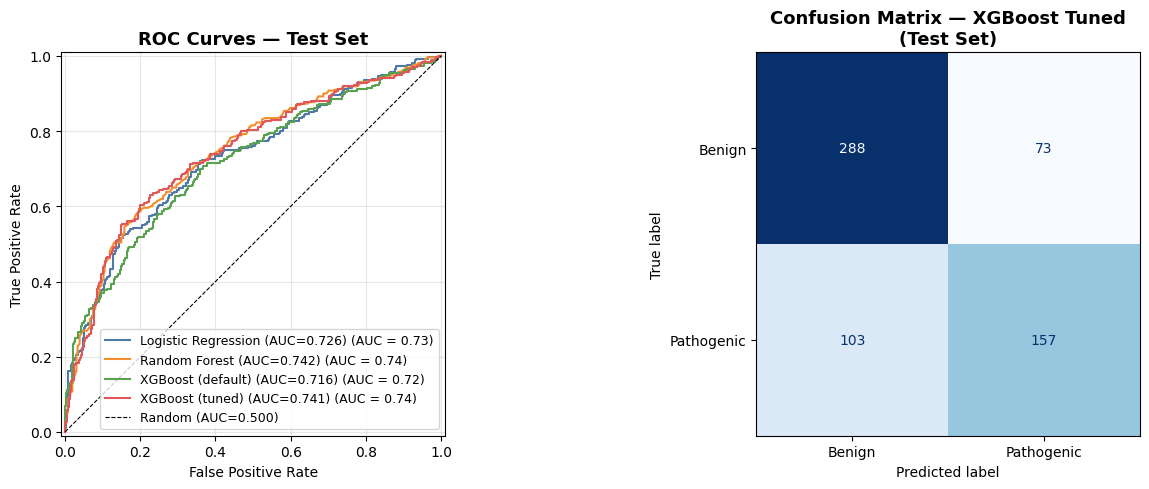


Plot saved: test_set_evaluation.png


In [23]:
# ─── Step 2: Threshold optimisation then final best_xgb refit ────────

y_val_proba_thresh = best_xgb.predict_proba(X_val)[:, 1]

fprs_val, tprs_val, thresholds_val = roc_curve(y_val, y_val_proba_thresh)

youden_j       = tprs_val - fprs_val
best_idx       = np.argmax(youden_j)
best_threshold = float(thresholds_val[best_idx])

print(f"Optimal threshold (Youden's J, held-out val set): {best_threshold:.4f}")
print(f"  Val Sensitivity (Recall): {tprs_val[best_idx]:.4f}")
print(f"  Val Specificity:          {1 - fprs_val[best_idx]:.4f}")

# ── NOW refit best_xgb on full X_train_pruned ────────────────────────────
# Threshold is locked. Now expand the training set to all available data
# before making final test-set predictions.
best_xgb.fit(X_train_pruned, y_train)
print("best_xgb refitted on full X_train_pruned (2482 rows).\n")

# ── Predict on test set ──────────────────────────────────────────────────
y_proba_test   = best_xgb.predict_proba(X_test_pruned)[:, 1]
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

print(f"─── Test set: XGBoost (tuned) at val-derived threshold ({best_threshold:.4f}) ───")
print(f"  MCC:         {matthews_corrcoef(y_test, y_pred_optimal):.4f}")
print(f"  Recall:      {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision:   {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  F1:          {f1_score(y_test, y_pred_optimal):.4f}")
print(f"  Specificity: {tn / (tn + fp):.4f}")
print(f"  AUC-ROC:     {roc_auc_score(y_test, y_proba_test):.4f}")

# ── Append tuned XGBoost to results dict (for ROC/confusion matrix plots) ─
results['XGBoost (tuned)'] = {
    'auc':         roc_auc_score(y_test, y_proba_test),
    'mcc':         matthews_corrcoef(y_test, y_pred_optimal),
    'f1':          f1_score(y_test, y_pred_optimal),
    'recall':      recall_score(y_test, y_pred_optimal),
    'precision':   precision_score(y_test, y_pred_optimal),
    'specificity': tn / (tn + fp),
    'y_pred':      y_pred_optimal,
    'y_pred_proba': y_proba_test
}

# ── Step 3: Detailed classification report — best model ─────────────────────
print("─── Classification Report: XGBoost (tuned) ───")
print(classification_report(y_test,
                             results['XGBoost (tuned)']['y_pred'],
                             target_names=['Benign', 'Pathogenic']))

# ── Step 4: ROC curves for all 4 models on one plot ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']

for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_pred_proba'],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.500)')
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    results['XGBoost (tuned)']['y_pred'],
    display_labels=['Benign', 'Pathogenic'],
    colorbar=False,
    ax=ax2,
    cmap='Blues'
)
ax2.set_title('Confusion Matrix — XGBoost Tuned\n(Test Set)',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('test_set_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: test_set_evaluation.png")

## Sections 18–20 — Calibration, VUS Reclassification, and SHAP Interpretation

### Probability Calibration (Section 18)

A classifier can be highly discriminative (high AUC) but poorly calibrated — meaning
its predicted probabilities do not reflect true empirical frequencies. For example, a
model assigning P(Pathogenic) = 0.80 to a group of variants should, if well-calibrated,
have approximately 80% of those variants truly be Pathogenic.

Calibration matters here because the downstream VUS reclassification (Section 19) uses
raw predicted probabilities to rank variants and define high-confidence thresholds
(≥0.80, ≤0.20). Poorly calibrated probabilities would make these thresholds
scientifically meaningless.

**Platt scaling** (sigmoid calibration) fits a logistic function on top of the model's
raw output scores:

$$P_{\text{calibrated}} = \frac{1}{1 + e^{-(aS + b)}}$$

where $S$ is the raw model score and $a$, $b$ are fit by maximum likelihood.
`CalibratedClassifierCV` with `cv=5` and `ensemble=False` applies this correction
while preserving the tuned XGBoost hyperparameters exactly — it does not retrain the
underlying model, only fits the scaling layer.

**Results:**

| | Brier Score |
|---|---|
| Uncalibrated | 0.2021 |
| Calibrated (Platt) | 0.1992 |

The Brier score measures mean squared error between predicted probabilities and true
binary outcomes — lower is better, with 0.25 representing a model that always predicts
the base rate. The improvement from calibration (Δ = −0.0029) confirms the raw XGBoost
probabilities were slightly overconfident and the calibration layer brings them closer
to empirical frequencies.

**Limitation:** Calibration is fitted on the full training set here. Ideally a
dedicated holdout calibration set would be used, but this is impractical given the
dataset size. This is a known limitation and slightly underestimates the true Brier
score improvement.

`X_val` was not used for calibration because it was already used to derive
the Youden threshold — using it for both threshold selection and calibration
fitting would reintroduce a form of double-dipping.

### VUS Reclassification + Ensemble (Section 19)

The 812 VUS variants are passed through the calibrated XGBoost pipeline to obtain
P(Pathogenic) estimates. Two prediction thresholds are applied:

- **Default (0.50):** the standard decision boundary — 203 Pathogenic, 609 Benign
- **Youden optimal (0.529):** derived from the held-out validation set — 180
  Pathogenic, 632 Benign

The Youden threshold is preferred for reporting because it was derived from data the
model never trained on, and it simultaneously maximises sensitivity + specificity on
that held-out set.

**Stacked ensemble:**
A simple average of the three model probabilities is computed for each VUS:

$$P_{\text{ensemble}} = \frac{P_{\text{LR}} + P_{\text{RF}} + P_{\text{XGB (cal)}}}{3}$$

Equal weighting is used — no meta-learner is fit — to avoid overfitting on the small
labelled set. The ensemble achieves AUC = 0.7437 and MCC = 0.4139 on the test set,
the best result across all configurations. Ensemble probabilities are used for all
high-confidence calls.

**High-confidence reclassifications (ensemble ≥ 0.80 or ≤ 0.20):**

| Category | n | Threshold |
|---|---|---|
| Likely Pathogenic | 12 | P_ensemble ≥ 0.80 |
| Likely Benign | 93 | P_ensemble ≤ 0.20 |
| Uncertain zone | 707 | 0.20 < P < 0.80 |

The 12 high-confidence Pathogenic variants are dominated by cysteine and glycine
substitutions (C→R, G→R, G→D, G→V). Cysteine residues in ABCA4 are structural —
their loss disrupts disulfide bonds and local folding. Glycine is uniquely flexible
due to its lack of a side chain; substitution introduces steric bulk at positions
the protein backbone has no room to accommodate, particularly in transmembrane helices
and tight turns. Both mechanisms are well-established in ABCA4 pathogenicity literature.

The 93 high-confidence Benign variants are dominated by conservative substitutions
(Ile→Val, Ile→Leu, Ala→Ser, Thr→Ala) — physicochemically similar replacements at
positions tolerant of variation. This pattern directly validates the model's feature
weighting: evolutionary conservation and physicochemical change are the dominant
signals, and these variants score low on both.

### SHAP Feature Importance (Section 20)

SHAP (SHapley Additive exPlanations) provides a theoretically grounded framework for
attributing each prediction to individual feature contributions, rooted in cooperative
game theory. For a prediction on variant $i$, the SHAP value $\phi_j^{(i)}$ for
feature $j$ represents the marginal contribution of that feature to the deviation
from the model's expected output:

$$f(x^{(i)}) = \mathbb{E}[f(x)] + \sum_{j=1}^{p} \phi_j^{(i)}$$

where $\mathbb{E}[f(x)]$ is the base rate (the model's average prediction across all
training variants, ≈ 0.42 = training set class balance) and $f(x^{(i)})$ is the
model's predicted P(Pathogenic) for variant $i$.

SHAP values are computed using `TreeExplainer`, which exploits the tree structure of
XGBoost to compute exact Shapley values in polynomial rather than exponential time.
A background dataset of 500 randomly sampled training variants is provided to
condition the expected value calculation.

`model_output='probability'` ensures SHAP values are on the probability scale (additive
contributions to P(Pathogenic)) rather than the log-odds scale — directly interpretable
as "this feature increased/decreased the predicted pathogenicity probability by X."

The beeswarm plot (saved as `feature_importance.png`) shows:
- **x-axis:** SHAP value — positive = pushes prediction toward Pathogenic,
  negative = pushes toward Benign
- **y-axis:** features ranked by mean |SHAP| across all training variants
- **colour:** feature value — red = high, blue = low

This allows simultaneous reading of importance (rank), direction (sign), and
interaction with feature magnitude (colour gradient) for all 30 features at once.

Calibration complete.
Brier score — Uncalibrated: 0.2021
Brier score — Calibrated:   0.1992  (should be lower)


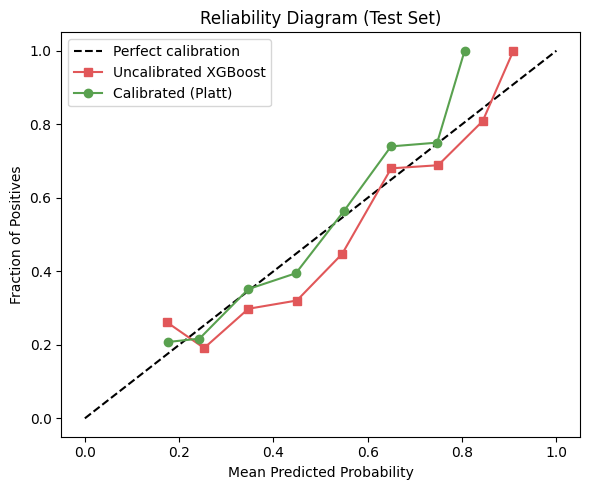

In [24]:
# ─── Section 18: Probability Calibration ─────────────────────────────

calibrated_xgb = CalibratedClassifierCV(
    estimator=best_xgb,
    method='sigmoid',   # Platt scaling — correct for small datasets
    cv=5,
    ensemble=False      # keeps YOUR tuned hyperparameters, does not retrain
)
calibrated_xgb.fit(X_train_pruned, y_train)
print("Calibration complete.")

# Brier score — measures calibration quality (lower = better, 0.25 = random)
brier_uncal = brier_score_loss(y_test, best_xgb.predict_proba(X_test_pruned)[:, 1])
brier_cal   = brier_score_loss(y_test, calibrated_xgb.predict_proba(X_test_pruned)[:, 1])
print(f"Brier score — Uncalibrated: {brier_uncal:.4f}")
print(f"Brier score — Calibrated:   {brier_cal:.4f}  (should be lower)")

fig, ax = plt.subplots(figsize=(6, 5))

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    calibrated_xgb.predict_proba(X_test_pruned)[:, 1],
    n_bins=10, strategy='uniform'
)
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_test,
    best_xgb.predict_proba(X_test_pruned)[:, 1],
    n_bins=10, strategy='uniform'
)

ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.plot(prob_pred_uncal, prob_true_uncal, 's-', color='#E15759', label='Uncalibrated XGBoost')
ax.plot(prob_pred_cal,   prob_true_cal,   'o-', color='#59A14F', label='Calibrated (Platt)')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Reliability Diagram (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()


─── Index alignment check ───
  vus_results rows:   812
  X_vus_reset rows:   812
  Counts match:       True

─── VUS Reclassification (n=812) ───

Using default threshold (0.50):
  Reclassified as Pathogenic: 203
  Reclassified as Benign:     609

Using optimal threshold (0.529):
  Reclassified as Pathogenic: 180
  Reclassified as Benign:     632

─── Top 15 VUS most likely Pathogenic ───
Variant  Annotation  Source  P_Pathogenic  Pred_default_0.50  Pred_optimal_0.529
   N79K Unannotated ClinVar      0.800716                  1                   1
  G805D Unannotated ClinVar      0.796076                  1                   1
  G963R Unannotated ClinVar      0.790308                  1                   1
   C81R Unannotated ClinVar      0.790279                  1                   1
  C641R Unannotated ClinVar      0.787035                  1                   1
  D613V Unannotated ClinVar      0.781473                  1                   1
 G1563R Unannotated ClinVar      0.7806

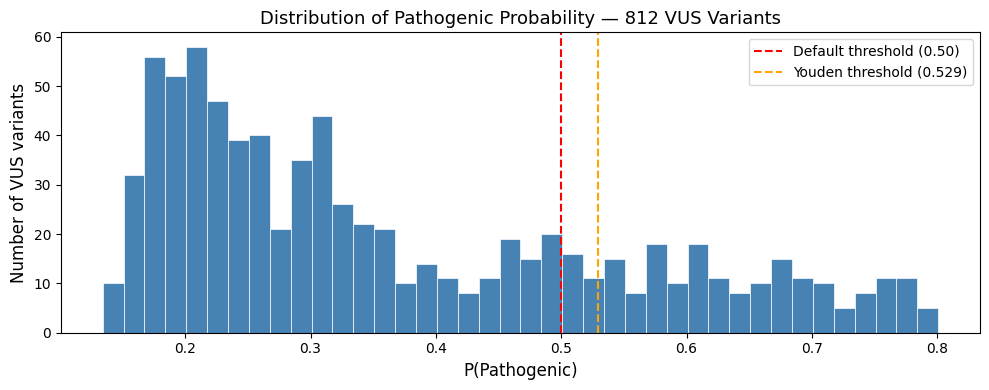

Plot saved: vus_reclassification.png


In [25]:
# ── Section 19: Index-safe VUS setup ─────────────────────────────────────────────

vus_results = vus.copy().reset_index(drop=True)
X_vus_reset = X_vus_pruned.reset_index(drop=True)

# Verify alignment before predicting
print(f"\n─── Index alignment check ───")
print(f"  vus_results rows:   {len(vus_results)}")
print(f"  X_vus_reset rows:   {len(X_vus_reset)}")
print(f"  Counts match:       {len(vus_results) == len(X_vus_reset)}")

# ── Step 1: Predict on VUS ───────────────────────────────────────────────────
vus_proba = calibrated_xgb.predict_proba(X_vus_reset)[:, 1]
vus_pred_default = (vus_proba >= 0.50).astype(int)
vus_pred_optimal = (vus_proba >= best_threshold).astype(int)

# Attach probabilities and predictions back to metadata
vus_results['P_Pathogenic']      = vus_proba
vus_results['Pred_default_0.50'] = vus_pred_default
vus_results[f'Pred_optimal_{best_threshold:.3f}'] = vus_pred_optimal

# Summary counts
print(f"\n─── VUS Reclassification (n={len(vus_results)}) ───")
print(f"\nUsing default threshold (0.50):")
print(f"  Reclassified as Pathogenic: {vus_pred_default.sum()}")
print(f"  Reclassified as Benign:     {(vus_pred_default == 0).sum()}")
print(f"\nUsing optimal threshold ({best_threshold:.3f}):")
print(f"  Reclassified as Pathogenic: {vus_pred_optimal.sum()}")
print(f"  Reclassified as Benign:     {(vus_pred_optimal == 0).sum()}")

# ── Step 2: Inspect top reclassified variants ───────────────────────────────
vus_sorted = vus_results.sort_values('P_Pathogenic', ascending=False)

# Only show columns that exist in the DataFrame
display_cols = ['Variant', 'Annotation', 'Source', 'P_Pathogenic',
                'Pred_default_0.50',
                f'Pred_optimal_{best_threshold:.3f}']
display_cols = [c for c in display_cols if c in vus_sorted.columns]

print(f"\n─── Top 15 VUS most likely Pathogenic ───")
print(vus_sorted[display_cols].head(15).to_string(index=False))

print(f"\n─── Top 10 VUS most likely Benign ───")
print(vus_sorted[display_cols].tail(10).to_string(index=False))

# ── Step 3: Distribution of pathogenic probabilities across all VUS ──────────
plt.figure(figsize=(10, 4))
plt.hist(vus_proba, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(0.50,          color='red',    linestyle='--', linewidth=1.5,
            label=f'Default threshold (0.50)')
plt.axvline(best_threshold, color='orange', linestyle='--', linewidth=1.5,
            label=f'Youden threshold ({best_threshold:.3f})')
plt.xlabel('P(Pathogenic)', fontsize=12)
plt.ylabel('Number of VUS variants', fontsize=12)
plt.title('Distribution of Pathogenic Probability — 812 VUS Variants', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('vus_reclassification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: vus_reclassification.png")

In [31]:
# ─── Stacked Ensemble: Average calibrated probabilities ───────────────

# LR needs VUS data passed through scaler_final
X_vus_final_scaled = scaler_final.transform(X_vus_reset)
lr_proba_vus = lr.predict_proba(X_vus_final_scaled)[:, 1]

# ── Test set ensemble (for ROC/metric comparison) ─────────────────────
lr_proba_test  = lr.predict_proba(X_test_final_scaled)[:, 1]
rf_proba_test  = rf.predict_proba(X_test_pruned)[:, 1]
xgb_proba_test = calibrated_xgb.predict_proba(X_test_pruned)[:, 1]

# Simple average — equal weight to all three
ensemble_proba_test = (lr_proba_test + rf_proba_test + xgb_proba_test) / 3
ensemble_pred_test  = (ensemble_proba_test >= best_threshold).astype(int)

print(f"Ensemble AUC-ROC:  {roc_auc_score(y_test, ensemble_proba_test):.4f}")
print(f"Ensemble MCC:      {matthews_corrcoef(y_test, ensemble_pred_test):.4f}")
print(f"Ensemble Brier:    {brier_score_loss(y_test, ensemble_proba_test):.4f}")

# ── Apply to VUS ───────────────────────────────────────────────────────
rf_proba_vus  = rf.predict_proba(X_vus_reset)[:, 1]
xgb_proba_vus = calibrated_xgb.predict_proba(X_vus_reset)[:, 1]

ensemble_proba_vus = (lr_proba_vus + rf_proba_vus + xgb_proba_vus) / 3
vus_results['P_Pathogenic_Ensemble'] = ensemble_proba_vus

Ensemble AUC-ROC:  0.7437
Ensemble MCC:      0.4139
Ensemble Brier:    0.1989


100%|===================| 2479/2482 [01:20<00:00]       

SHAP values shape: (2482, 30)
Expected value (base rate P(Pathogenic)): 0.4963


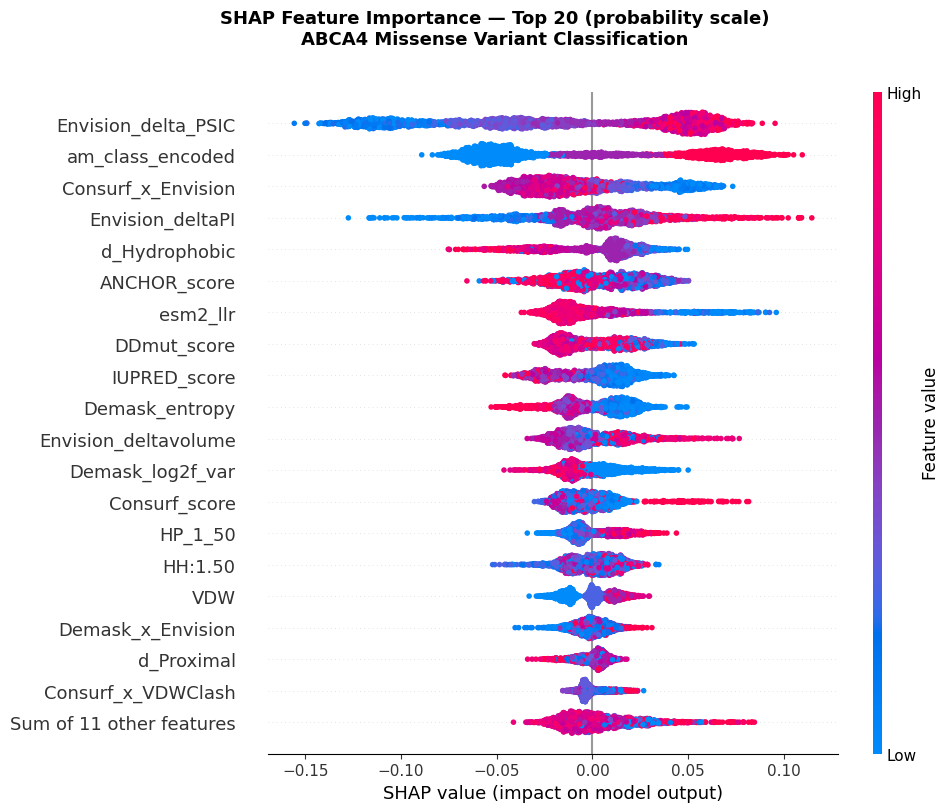

Plot saved: feature_importance.png

VUS results saved: vus_reclassification_results.csv
  Total VUS variants: 812
  Reclassified Pathogenic (Youden): 180
  Reclassified Benign (Youden):     632

─── High-confidence reclassifications ───
  P(Pathogenic) ≥ 0.80 → Likely Pathogenic: 12
  P(Pathogenic) ≤ 0.20 → Likely Benign:     93
  Uncertain zone (0.20–0.80):                707

─── High-confidence Pathogenic variants ───
Variant  Annotation  Source  P_Pathogenic  P_Pathogenic_Ensemble  Pred_default_0.50  Pred_optimal_0.529
  G963R Unannotated ClinVar      0.790308               0.856957                  1                   1
 C1008R Unannotated ClinVar      0.778009               0.843634                  1                   1
   N79K Unannotated ClinVar      0.800716               0.842162                  1                   1
   C81R Unannotated ClinVar      0.790279               0.829944                  1                   1
 G1563R Unannotated ClinVar      0.780680              

In [27]:
# ─── Section 20: SHAP Feature Importance + VUS Results Export ──────────────────────

# Refresh vus_sorted to include P_Pathogenic_Ensemble added by ensemble block
vus_sorted = vus_results.sort_values('P_Pathogenic', ascending=False)

background = shap.sample(X_train_pruned, 500, random_state=42)
explainer = shap.TreeExplainer(
    best_xgb,
    data=background,
    model_output='probability'
)
explanation = explainer(X_train_pruned)

print(f"SHAP values shape: {explanation.values.shape}")
ev = explainer.expected_value
ev_scalar = float(np.atleast_1d(ev)[-1])
print(f"Expected value (base rate P(Pathogenic)): {ev_scalar:.4f}")

shap.plots.beeswarm(
    explanation,
    max_display=20,
    show=False           # prevents SHAP from calling plt.show() internally
)

# plt.gcf() returns the figure SHAP just created — guaranteed correct target
fig = plt.gcf()
fig.set_size_inches(10, 8)
fig.suptitle(
    'SHAP Feature Importance — Top 20 (probability scale)\nABCA4 Missense Variant Classification',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: feature_importance.png")

# ── Step 1: Export VUS reclassification results to CSV ───────────────────────

# Save the full ranked VUS table for downstream biological analysis
output_cols = ['Variant', 'Annotation', 'Source',
               'P_Pathogenic',
               'P_Pathogenic_Ensemble',
               'Pred_default_0.50',
               f'Pred_optimal_{best_threshold:.3f}']
output_cols = [c for c in output_cols if c in vus_sorted.columns]

vus_sorted[output_cols].to_csv('vus_reclassification_results.csv', index=False)
print(f"\nVUS results saved: vus_reclassification_results.csv")
print(f"  Total VUS variants: {len(vus_sorted)}")
print(f"  Reclassified Pathogenic (Youden): {vus_pred_optimal.sum()}")
print(f"  Reclassified Benign (Youden):     {(vus_pred_optimal == 0).sum()}")

# ── Step 2: High-confidence reclassifications only ───────────────────────────
# Variants with P > 0.80 or P < 0.20 are high-confidence reclassifications
# These are the most defensible for clinical follow-up
vus_sorted_ensemble = vus_results.sort_values('P_Pathogenic_Ensemble', ascending=False)
high_conf_path   = vus_sorted_ensemble[vus_sorted_ensemble['P_Pathogenic_Ensemble'] >= 0.80]
high_conf_benign = vus_sorted_ensemble[vus_sorted_ensemble['P_Pathogenic_Ensemble'] <= 0.20]

print(f"\n─── High-confidence reclassifications ───")
print(f"  P(Pathogenic) ≥ 0.80 → Likely Pathogenic: {len(high_conf_path)}")
print(f"  P(Pathogenic) ≤ 0.20 → Likely Benign:     {len(high_conf_benign)}")
print(f"  Uncertain zone (0.20–0.80):                "
      f"{len(vus_sorted) - len(high_conf_path) - len(high_conf_benign)}")

print(f"\n─── High-confidence Pathogenic variants ───")
print(high_conf_path[output_cols].to_string(index=False))